In [1]:
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u

SED_KEV_TO_ERG = u.keV.to(u.erg)
KEV_TO_MEV = u.keV.to(u.MeV)
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter
from threeML.minimizer.minimization import CannotComputeCovariance

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()

from scipy.integrate import quad

import matplotlib.ticker as mticker

from pathlib import Path

import os

# Use finite background support to avoid machine-tiny TS inflation.
BACKGROUND_PSEUDOCOUNT = 1e-12

%matplotlib inline


14:13:31 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=572224;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=63379;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=61861;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=329271;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

14:13:32 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=665497;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=408653;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

14:13:32 INFO      Starting 3ML!                                                                     ]8;id=875379;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=728858;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=306308;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=153103;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=984087;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=927935;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

14:13:33 WARNING   No fermitools installed                                              ]8;id=128385;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=839342;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=264513;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=532618;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=796163;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=898714;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=374750;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=717545;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
from astropy import units as u
from astropy.coordinates import SkyCoord
from cosipy.event_selection import GoodTimeInterval
from agn_cosi_fit_utils import draw_energy_hist_mev, open_spacecraft_history, scale_spacecraft_livetime

orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
source_coord = SkyCoord(l=155.077, b=75.063, frame="galactic", unit="deg")
fov_cut = 60 * u.deg

full_sc_orientation = open_spacecraft_history(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    full_sc_orientation,
    fov_cut,
    earth_occ=False,
)
sc_orientation = full_sc_orientation.apply_gti(source_gti)

print(f"NGC 4151 FOV cut: {fov_cut.to_value(u.deg):.0f} deg")
print(f"Selected livetime: {sc_orientation.cumulative_livetime().to_value(u.s):,.1f} s")

NGC 4151 FOV cut: 60 deg
Selected livetime: 980,415.0 s


In [3]:
dr = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
import json

sensitivity_dir = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/"
    "Sensitivity_Ensemble"
)

def median_files(case_folder, output_prefix, exposure_months):
    manifest_file = (
        sensitivity_dir / case_folder
        / f"{output_prefix}_median_realization_{exposure_months}months.json"
    )
    if not manifest_file.exists():
        raise FileNotFoundError(
            f"Run the {case_folder} sensitivity notebook first: {manifest_file}"
        )
    with manifest_file.open() as stream:
        manifest = json.load(stream)
    return Path(manifest["source_expectation_file"]), Path(manifest["median_data_file"])

ngc4151_ec200_3m_file, ngc4151_ec200_plus_bkg_3m_file = median_files(
    "Case1_ec200", "NGC4151_ec200_TH", 3
)
ngc4151_ec200_24m_file, ngc4151_ec200_plus_bkg_24m_file = median_files(
    "Case1_ec200", "NGC4151_ec200_TH", 24
)
ngc4151_ec1000_3m_file, ngc4151_ec1000_plus_bkg_3m_file = median_files(
    "Case1_ec1000", "NGC4151_ec1000_TH", 3
)
ngc4151_ec1000_24m_file, ngc4151_ec1000_plus_bkg_24m_file = median_files(
    "Case1_ec1000", "NGC4151_ec1000_TH", 24
)
background_file = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5"
)

simulation_files = (
    ngc4151_ec200_3m_file,
    ngc4151_ec200_plus_bkg_3m_file,
    ngc4151_ec200_24m_file,
    ngc4151_ec200_plus_bkg_24m_file,
    ngc4151_ec1000_3m_file,
    ngc4151_ec1000_plus_bkg_3m_file,
    ngc4151_ec1000_24m_file,
    ngc4151_ec1000_plus_bkg_24m_file,
)
for required_file in (*simulation_files, background_file):
    if not required_file.exists():
        raise FileNotFoundError(required_file)

ngc4151_ec200_3m = Histogram.open(ngc4151_ec200_3m_file)
ngc4151_ec200_plus_bkg_3m = Histogram.open(ngc4151_ec200_plus_bkg_3m_file)
ngc4151_ec200_24m = Histogram.open(ngc4151_ec200_24m_file)
ngc4151_ec200_plus_bkg_24m = Histogram.open(ngc4151_ec200_plus_bkg_24m_file)
ngc4151_ec1000_3m = Histogram.open(ngc4151_ec1000_3m_file)
ngc4151_ec1000_plus_bkg_3m = Histogram.open(ngc4151_ec1000_plus_bkg_3m_file)
ngc4151_ec1000_24m = Histogram.open(ngc4151_ec1000_24m_file)
ngc4151_ec1000_plus_bkg_24m = Histogram.open(ngc4151_ec1000_plus_bkg_24m_file)
background_3m = Histogram.open(background_file).project("Em", "Phi", "PsiChi")

In [4]:
multiplier_4151 = 1
exposure_4151 = multiplier_4151 * 3

# The three-month source and data histograms are loaded directly.
# Keep the matching three-month response livetime here.
sc_orientation = scale_spacecraft_livetime(sc_orientation, multiplier_4151)

# Source Model Plots

## Cutoff Power Law (Thermal)

#### NGC 4151 (200 keV)

In [5]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

#### NGC 4151 (1000 keV)

In [6]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.75

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

# Spectral Fitting

In [7]:
NGC4151_ec200 = ngc4151_ec200_3m.copy()
bkg = background_3m.copy()

NGC4151_ec200.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec200 = NGC4151_ec200.to(
    unit=bkg.unit,
    update=False,
)

NGC4151_ec200_bkg = ngc4151_ec200_plus_bkg_3m.copy()
NGC4151_ec200_bkg.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec200_bkg = NGC4151_ec200_bkg.to(
    unit=bkg.unit,
    update=False,
)

In [8]:
NGC4151_ec1000 = ngc4151_ec1000_3m.copy()
NGC4151_ec1000.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec1000 = NGC4151_ec1000.to(
    unit=bkg.unit,
    update=False,
)

NGC4151_ec1000_bkg = ngc4151_ec1000_plus_bkg_3m.copy()
NGC4151_ec1000_bkg.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec1000_bkg = NGC4151_ec1000_bkg.to(
    unit=bkg.unit,
    update=False,
)

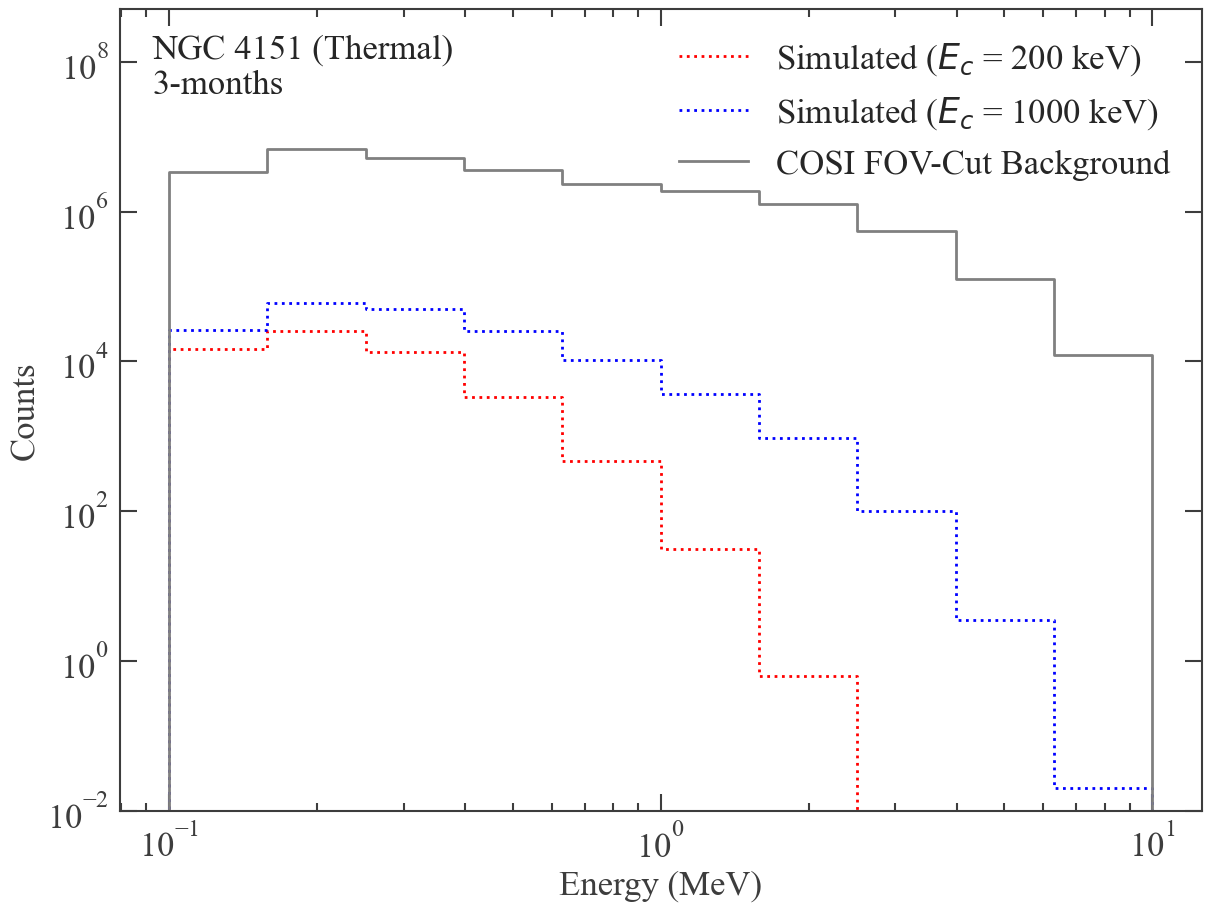

In [9]:
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

draw_energy_hist_mev(NGC4151_ec200, ax, label="Simulated ($E_c$ = 200 keV)", color="red", linestyle="dotted")
draw_energy_hist_mev(NGC4151_ec1000, ax, label="Simulated ($E_c$ = 1000 keV)", color="blue", linestyle="dotted")
draw_energy_hist_mev(bkg, ax, label="COSI FOV-Cut Background", color="grey")
# draw_energy_hist_mev(full_bkg, ax, label="DC4 Full Background", color="black", linestyle="dashdot")
# draw_energy_hist_mev(NGC4151_ec200_bkg, ax, label="NGC 4151 Model ($E_c$ = 200 keV) + Background", linestyle='dashdot', color="red")
# draw_energy_hist_mev(NGC4151_ec1000_bkg, ax, label="NGC 4151 Model ($E_c$ = 1000 keV) + Background", linestyle='dashdot', color="blue")

text = f'NGC 4151 (Thermal) \n{exposure_4151}-months'
ax.text(
    0.03, 0.97,
    text,
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

# ax.set_xlim((180) * KEV_TO_MEV, (5500) * KEV_TO_MEV)
ax.set_yscale("log")
ax.set_xscale("log")

ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e-2, 5e8)

# ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1, 5]))
# ax.xaxis.set_major_formatter(
#     mticker.FixedFormatter(["0.2", "1.0", "5.0"])
# )

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE, loc='upper right', frameon=False)

save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_Cpl_Counts_200_1000_3Months.pdf"
# plt.savefig(save_path)

## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [10]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

bkg_par_ec1000 = Parameter("background_cosi_ec1000",                           # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSIPlugin("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 background_pseudocount = BACKGROUND_PSEUDOCOUNT,              # finite support for empty background cells
                 earth_occ = True)                                             # Option to account for Earth occultation

cosi_ec1000 = COSIPlugin("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec1000_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par_ec1000,                                     # background parameter
                 background_pseudocount = BACKGROUND_PSEUDOCOUNT,              # finite support for empty background cells
                 earth_occ = True)                                             # Option to account for Earth occultation

### Powerlaw with energy cutoff fit

In [11]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 100. * u.keV
index = -1.75

spectrum_cpl = Cutoff_powerlaw()

spectrum_cpl.K.value = K.value
spectrum_cpl.piv.value = piv.value
spectrum_cpl.xc.value = xc.value
spectrum_cpl.index.value = index
# spectrum_cpl.index.fix = True

# Harsher Parameters
spectrum_cpl.K.min_value = 1e-8
spectrum_cpl.K.max_value = 1e-2
spectrum_cpl.xc.min_value = 50 # keep these relatively the same
spectrum_cpl.xc.max_value = 2000 # change to 1000
spectrum_cpl.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum_cpl.index.max_value = 1

# spectrum_cpl.K.delta = 0.05
# spectrum_cpl.xc.delta = 10
# spectrum_cpl.index.delta = 0.15

spectrum_cpl.K.unit = K.unit
spectrum_cpl.piv.unit = piv.unit
spectrum_cpl.xc.unit = xc.unit

source1 = PointSource("source1",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl)    # Spectral model

In [12]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 1000. * u.keV
index = -1.75

spectrum_cpl_ec1000 = Cutoff_powerlaw()

spectrum_cpl_ec1000.K.value = K.value
spectrum_cpl_ec1000.piv.value = piv.value
spectrum_cpl_ec1000.xc.value = xc.value
spectrum_cpl_ec1000.index.value = index
# spectrum_cpl_ec1000.index.fix = True

# Harsher Parameters
spectrum_cpl_ec1000.K.min_value = 1e-8
spectrum_cpl_ec1000.K.max_value = 1e-2
spectrum_cpl_ec1000.xc.min_value = 50 # keep these relatively the same
spectrum_cpl_ec1000.xc.max_value = 2000 # change to 1000
spectrum_cpl_ec1000.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum_cpl_ec1000.index.max_value = 1

# spectrum_cpl_ec1000.K.delta = 0.05
# spectrum_cpl_ec1000.xc.delta = 10
# spectrum_cpl_ec1000.index.delta = 0.15

spectrum_cpl_ec1000.K.unit = K.unit
spectrum_cpl_ec1000.piv.unit = piv.unit
spectrum_cpl_ec1000.xc.unit = xc.unit

source2 = PointSource("source2",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl_ec1000)    # Spectral model

## Just Thermal Fit

In [13]:
# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
model = Model(source1)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)
model_ec1000 = Model(source2)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

cosi.set_model(model)
cosi_ec1000.set_model(model_ec1000)

### Joint Fit

In [14]:
# bat_ec200.use_effective_area_correction(0.2, 1.8)
# plugins = DataList(bat_ec200, cosi)

# bat_ec1000.use_effective_area_correction(0.2, 1.8)
# plugins_ec1000 = DataList(bat_ec1000, cosi_ec1000)

### Normal Fit

In [15]:
## Only COSI fit
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)
plugins_ec1000 = DataList(cosi_ec1000)

In [16]:
like = JointLikelihood(model, plugins, verbose = False)
like_ec1000 = JointLikelihood(model_ec1000, plugins_ec1000, verbose = False)

result = like.fit()
result_ec1000 = like_ec1000.fit()


# Explicit 24-month global fits use the directly loaded 24-month source
# and data histograms. The multiplier is only for the three-month background
# template and response livetime.
from astromodels import clone_model

multiplier_4151_24m = 8
exposure_4151_24m = multiplier_4151_24m * 3
sc_orientation_24m = scale_spacecraft_livetime(
    full_sc_orientation.apply_gti(source_gti),
    multiplier_4151_24m,
)

bkg_24m = background_3m * multiplier_4151_24m

NGC4151_ec200_24m = ngc4151_ec200_24m.copy()
NGC4151_ec200_24m.axes['Em'].axis_scale = bkg_24m.axes['Em'].axis_scale
NGC4151_ec200_24m = NGC4151_ec200_24m.to(unit=bkg_24m.unit, update=False)
NGC4151_ec200_bkg_24m = ngc4151_ec200_plus_bkg_24m.copy()
NGC4151_ec200_bkg_24m.axes['Em'].axis_scale = bkg_24m.axes['Em'].axis_scale
NGC4151_ec200_bkg_24m = NGC4151_ec200_bkg_24m.to(
    unit=bkg_24m.unit, update=False,
)

NGC4151_ec1000_24m = ngc4151_ec1000_24m.copy()
NGC4151_ec1000_24m.axes['Em'].axis_scale = bkg_24m.axes['Em'].axis_scale
NGC4151_ec1000_24m = NGC4151_ec1000_24m.to(unit=bkg_24m.unit, update=False)
NGC4151_ec1000_bkg_24m = ngc4151_ec1000_plus_bkg_24m.copy()
NGC4151_ec1000_bkg_24m.axes['Em'].axis_scale = bkg_24m.axes['Em'].axis_scale
NGC4151_ec1000_bkg_24m = NGC4151_ec1000_bkg_24m.to(
    unit=bkg_24m.unit, update=False,
)

bkg_par_24m = Parameter(
    'background_cosi_24m', 1.0, min_value=0.0, max_value=5.0, delta=0.05,
    desc='Background parameter for the 24-month COSI fit',
)
bkg_par_ec1000_24m = Parameter(
    'background_cosi_ec1000_24m', 1.0, min_value=0.0, max_value=5.0, delta=0.05,
    desc='Background parameter for the 24-month COSI fit',
)

cosi_24m = COSIPlugin(
    'cosi_24m',
    dr=dr,
    data=NGC4151_ec200_bkg_24m.project('Em', 'Phi', 'PsiChi'),
    bkg=bkg_24m.project('Em', 'Phi', 'PsiChi'),
    sc_orientation=sc_orientation_24m,
    nuisance_param=bkg_par_24m,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT,
    earth_occ=True,
)
cosi_ec1000_24m = COSIPlugin(
    'cosi_ec1000_24m',
    dr=dr,
    data=NGC4151_ec1000_bkg_24m.project('Em', 'Phi', 'PsiChi'),
    bkg=bkg_24m.project('Em', 'Phi', 'PsiChi'),
    sc_orientation=sc_orientation_24m,
    nuisance_param=bkg_par_ec1000_24m,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT,
    earth_occ=True,
)

model_24m = clone_model(like.results.optimized_model)
model_ec1000_24m = clone_model(like_ec1000.results.optimized_model)
# Cloned ThreeML result models retain the original plugin nuisance parameter.
# Remove it before JointLikelihood adds the new 24-month background scale;
# otherwise Minuit sees two degenerate background parameters and Hesse fails.
model_24m.remove_external_parameter(bkg_par.name)
model_ec1000_24m.remove_external_parameter(bkg_par_ec1000.name)
like_24m = JointLikelihood(model_24m, DataList(cosi_24m), verbose=False)
like_ec1000_24m = JointLikelihood(
    model_ec1000_24m, DataList(cosi_ec1000_24m), verbose=False,
)
result_24m = like_24m.fit()
result_ec1000_24m = like_ec1000_24m.fit()

print('3-month E_c=200 keV global fit')
like.results.display()
print('3-month E_c=1000 keV global fit')
like_ec1000.results.display()
print('24-month E_c=200 keV global fit')
like_24m.results.display()
print('24-month E_c=1000 keV global fit')
like_ec1000_24m.results.display()

14:13:41 INFO      set the minimizer to minuit                                             ]8;id=826352;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=42059;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=274214;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=140263;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(2.6 -1.4 +3.0) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.index,(-9 +/- 9) x 10^-1,
source1.spectrum.main.Cutoff_powerlaw.xc,(1.2 -0.4 +0.7) x 10^2,keV
background_cosi,(2.5571 +/- 0.0007) x 10,Hz


Correlation matrix:

...

1.00,0.76,-0.88,0.00
0.76,1.00,-0.95,0.29
-0.88,-0.95,1.00,-0.32
0.00,0.29,-0.32,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_ec1000_24m,-1323646829.2569242
total,-1323646829.2569242


Values of statistical measures:

,statistical measures
AIC,-2647293650.5136747
BIC,-2647293609.1235595


In [17]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter

def _total_negative_log_likelihood(joint_likelihood):
    statistic_frame = joint_likelihood.results.get_statistic_frame()
    statistic_column = statistic_frame["-log(likelihood)"]
    if "total" in statistic_column.index:
        return float(statistic_column.loc["total"])
    return float(statistic_column.sum())


def make_null_likelihood(data_hist, background_hist, orientation, dataset_name):
    null_background_parameter = Parameter(
        f"background_{dataset_name}",
        1.0,
        min_value=0.0,
        max_value=5.0,
        delta=0.05,
        desc=f"Background parameter for {dataset_name}",
    )
    cosi_null = COSIPlugin(
        dataset_name,
        dr=dr,
        data=data_hist.project("Em", "Phi", "PsiChi"),
        bkg=background_hist.project("Em", "Phi", "PsiChi"),
        sc_orientation=orientation,
        nuisance_param=null_background_parameter,
        background_pseudocount=BACKGROUND_PSEUDOCOUNT,
        earth_occ=True,
    )

    spectrum_null = Powerlaw()
    spectrum_null.K.value = 1e-30
    spectrum_null.index.value = 1
    spectrum_null.K.fix = True
    spectrum_null.index.fix = True

    source_null = PointSource(
        f"source_null_{dataset_name}",
        l=l,
        b=b,
        spectral_shape=spectrum_null,
    )
    model_null = Model(source_null)
    cosi_null.set_model(model_null)

    like_null = JointLikelihood(model_null, DataList(cosi_null), verbose=False)
    like_null.fit()
    return like_null


# Null fits for both cutoff-energy cases and both exposure lengths.
like_null_200 = make_null_likelihood(
    NGC4151_ec200_bkg, bkg, sc_orientation, "cosi_null_3m_ec200"
)
like_null_1000 = make_null_likelihood(
    NGC4151_ec1000_bkg, bkg, sc_orientation, "cosi_null_3m_ec1000"
)
like_null_200_24m = make_null_likelihood(
    NGC4151_ec200_bkg_24m, bkg_24m, sc_orientation_24m, "cosi_null_24m_ec200"
)
like_null_1000_24m = make_null_likelihood(
    NGC4151_ec1000_bkg_24m, bkg_24m, sc_orientation_24m, "cosi_null_24m_ec1000"
)

# TS = 2 [log L(source) - log L(null)] = 2 [NLL(null) - NLL(source)].
# Clamp tiny negative numerical fluctuations to zero before taking sqrt(TS).
TS = max(
    0.0,
    2.0 * (
        _total_negative_log_likelihood(like_null_200)
        - _total_negative_log_likelihood(like)
    ),
)
TS_ec1000 = max(
    0.0,
    2.0 * (
        _total_negative_log_likelihood(like_null_1000)
        - _total_negative_log_likelihood(like_ec1000)
    ),
)
TS_24m = max(
    0.0,
    2.0 * (
        _total_negative_log_likelihood(like_null_200_24m)
        - _total_negative_log_likelihood(like_24m)
    ),
)
TS_ec1000_24m = max(
    0.0,
    2.0 * (
        _total_negative_log_likelihood(like_null_1000_24m)
        - _total_negative_log_likelihood(like_ec1000_24m)
    ),
)

sigma_3m_ec200 = np.sqrt(TS)
sigma_3m_ec1000 = np.sqrt(TS_ec1000)
sigma_24m_ec200 = np.sqrt(TS_24m)
sigma_24m_ec1000 = np.sqrt(TS_ec1000_24m)

for label, source_like, null_like, ts_value, sigma_value in [
    ("3 months, E_c=200 keV", like, like_null_200, TS, sigma_3m_ec200),
    ("3 months, E_c=1000 keV", like_ec1000, like_null_1000, TS_ec1000, sigma_3m_ec1000),
    ("24 months, E_c=200 keV", like_24m, like_null_200_24m, TS_24m, sigma_24m_ec200),
    (
        "24 months, E_c=1000 keV",
        like_ec1000_24m,
        like_null_1000_24m,
        TS_ec1000_24m,
        sigma_24m_ec1000,
    ),
]:
    print()
    print(label)
    print("L1:", -_total_negative_log_likelihood(source_like))
    print("L0:", -_total_negative_log_likelihood(null_like))
    print("TS:", ts_value)
    print("Significance (sqrt(TS)):", sigma_value, "sigma")


14:14:14 INFO      set the minimizer to minuit                                             ]8;id=484330;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=193518;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Best fit values:

,result,unit
parameter,,
background_cosi_null_3m_ec200,(2.5625 +/- 0.0005) x 10,Hz


Correlation matrix:

1.00


...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_null_24m_ec1000,-1323640341.1809576
total,-1323640341.1809576


Values of statistical measures:

,statistical measures
AIC,-2647280680.361898
BIC,-2647280670.014343



3 months, E_c=200 keV
L1: 112250095.03014526
L0: 112249952.10742372
TS: 285.84544306993484
Significance (sqrt(TS)): 16.90696433633001 sigma

3 months, E_c=1000 keV
L1: 113036478.49009529
L0: 113035678.80469143
TS: 1599.3708077073097
Significance (sqrt(TS)): 39.992134322980434 sigma

24 months, E_c=200 keV
L1: 1316251891.621036
L0: 1316250636.3878448
TS: 2510.4663825035095
Significance (sqrt(TS)): 50.104554508582446 sigma

24 months, E_c=1000 keV
L1: 1323646829.2569242
L0: 1323640341.1809576
TS: 12976.151933193207
Significance (sqrt(TS)): 113.91291381223293 sigma


In [18]:
# Save all four global fits, TS values, and significances in one text file.
from agn_cosi_fit_utils import save_agn_fit_summary

FIT_SUMMARY_DIR = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "Papers/AGN_Corona_EC_Overleaf/Fits/Fluctuate_True/"
)
fit_summary_path = save_agn_fit_summary(
    output_path=FIT_SUMMARY_DIR / "NGC4151_TH_global_fit_summary_3_24Months.txt",
    fit_results={
        "3m_ec200": like.results,
        "3m_ec1000": like_ec1000.results,
        "24m_ec200": like_24m.results,
        "24m_ec1000": like_ec1000_24m.results,
    },
    injected_models={
        "3m_ec200": {"thermal": spectrum_inj_ec200},
        "3m_ec1000": {"thermal": spectrum_inj_ec1000},
        "24m_ec200": {"thermal": spectrum_inj_ec200},
        "24m_ec1000": {"thermal": spectrum_inj_ec1000},
    },
    ts_values={
        "3m_ec200": TS,
        "3m_ec1000": TS_ec1000,
        "24m_ec200": TS_24m,
        "24m_ec1000": TS_ec1000_24m,
    },
    significance_values={
        "3m_ec200": sigma_3m_ec200,
        "3m_ec1000": sigma_3m_ec1000,
        "24m_ec200": sigma_24m_ec200,
        "24m_ec1000": sigma_24m_ec1000,
    },
    exposure_months={
        "3m_ec200": 3,
        "3m_ec1000": 3,
        "24m_ec200": 24,
        "24m_ec1000": 24,
    },
    notes=(
        "The 3-month fits use multiplier_4151=1; the 24-month fits use "
        "multiplier_4151_24m=8. Significance is reported as sqrt(TS)."
    ),
)
print(f"Saved combined 3/24-month fit summary: {fit_summary_path}")


Saved combined 3/24-month fit summary: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Fits/Fluctuate_True/NGC4151_TH_global_fit_summary_3_24Months.txt


In [19]:
# Expose both global-fit result sets to the later SED-only section.
results = like.results
results_ec1000 = like_ec1000.results
results_24m = like_24m.results
results_ec1000_24m = like_ec1000_24m.results

results_sed = results
results_sed_ec1000 = results_ec1000
results_sed_24m = results_24m
results_sed_ec1000_24m = results_ec1000_24m

data_sed_hist = cosi._data.copy()
bkg_sed_hist = cosi._bkg_hist.copy()
data_sed_ec1000_hist = cosi_ec1000._data.copy()
bkg_sed_ec1000_hist = cosi_ec1000._bkg_hist.copy()

data_sed_hist_24m = cosi_24m._data.copy()
bkg_sed_hist_24m = cosi_24m._bkg_hist.copy()
data_sed_ec1000_hist_24m = cosi_ec1000_24m._data.copy()
bkg_sed_ec1000_hist_24m = cosi_ec1000_24m._bkg_hist.copy()

parameters = {
    par.name: results.get_variates(par.path)
    for par in results.optimized_model["source1"].parameters.values()
    if par.free
}
parameters_ec1000 = {
    par.name: results_ec1000.get_variates(par.path)
    for par in results_ec1000.optimized_model["source2"].parameters.values()
    if par.free
}
parameters_24m = {
    par.name: results_24m.get_variates(par.path)
    for par in results_24m.optimized_model["source1"].parameters.values()
    if par.free
}
parameters_ec1000_24m = {
    par.name: results_ec1000_24m.get_variates(par.path)
    for par in results_ec1000_24m.optimized_model["source2"].parameters.values()
    if par.free
}

results_err = results.propagate(
    results.optimized_model["source1"].spectrum.main.shape.evaluate_at,
    **parameters,
)
results_err_ec1000 = results_ec1000.propagate(
    results_ec1000.optimized_model["source2"].spectrum.main.shape.evaluate_at,
    **parameters_ec1000,
)
results_err_24m = results_24m.propagate(
    results_24m.optimized_model["source1"].spectrum.main.shape.evaluate_at,
    **parameters_24m,
)
results_err_ec1000_24m = results_ec1000_24m.propagate(
    results_ec1000_24m.optimized_model["source2"].spectrum.main.shape.evaluate_at,
    **parameters_ec1000_24m,
)


## Normal-fit plot

In [20]:
# energy = np.geomspace(100 * u.keV, 10 * u.MeV).to_value(u.keV)

# flux_lo = np.zeros_like(energy)
# flux_median = np.zeros_like(energy)
# flux_hi = np.zeros_like(energy)
# flux_inj = np.zeros_like(energy)

# flux_lo_ec1000 = np.zeros_like(energy)
# flux_median_ec1000 = np.zeros_like(energy)
# flux_hi_ec1000 = np.zeros_like(energy)
# flux_inj_ec1000 = np.zeros_like(energy)

# for i, e in enumerate(energy):
#     flux = results_err(e)
#     flux_median[i] = flux.median
#     flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
#     flux_inj[i] = spectrum_inj_ec200.evaluate_at(e)

#     flux_ec1000 = results_err_ec1000(e)
#     flux_median_ec1000[i] = flux_ec1000.median
#     flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_ec1000.equal_tail_interval(cl=0.68)
#     flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)

# binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# # print(binned_energy_edges)
# binned_energy = np.array([])
# bin_sizes = np.array([])

# for i in range(len(binned_energy_edges)-1):
#     binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
#     bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

# expectation = cosi._expected_counts['source1']
# expectation_ec1000 = cosi_ec1000._expected_counts['source2']

In [21]:
def _fit_includes_dataset(fit_results, dataset_name):
    try:
        return dataset_name in fit_results.get_statistic_frame().index
    except Exception:
        return False

has_bat_fit_200 = _fit_includes_dataset(results, 'BAT')
has_bat_fit_1000 = _fit_includes_dataset(results_ec1000, 'BAT')
has_any_bat_fit = has_bat_fit_200 or has_bat_fit_1000
flux_energy_min_keV = 100
flux_energy_max_keV = 10000
energy = np.geomspace(flux_energy_min_keV * u.keV, flux_energy_max_keV * u.keV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

flux_lo_ec1000 = np.zeros_like(energy)
flux_median_ec1000 = np.zeros_like(energy)
flux_hi_ec1000 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)

flux_lo_24m = np.zeros_like(energy)
flux_median_24m = np.zeros_like(energy)
flux_hi_24m = np.zeros_like(energy)

flux_lo_ec1000_24m = np.zeros_like(energy)
flux_median_ec1000_24m = np.zeros_like(energy)
flux_hi_ec1000_24m = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj_ec200.evaluate_at(e)

    flux_ec1000 = results_err_ec1000(e)
    flux_median_ec1000[i] = flux_ec1000.median
    flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_ec1000.equal_tail_interval(cl=0.68)
    flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)

    flux_24m = results_err_24m(e)
    flux_median_24m[i] = flux_24m.median
    flux_lo_24m[i], flux_hi_24m[i] = flux_24m.equal_tail_interval(cl=0.68)

    flux_ec1000_24m = results_err_ec1000_24m(e)
    flux_median_ec1000_24m[i] = flux_ec1000_24m.median
    flux_lo_ec1000_24m[i], flux_hi_ec1000_24m[i] = (
        flux_ec1000_24m.equal_tail_interval(cl=0.68)
    )

binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source1']
expectation_ec1000 = cosi_ec1000._expected_counts['source2']


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'



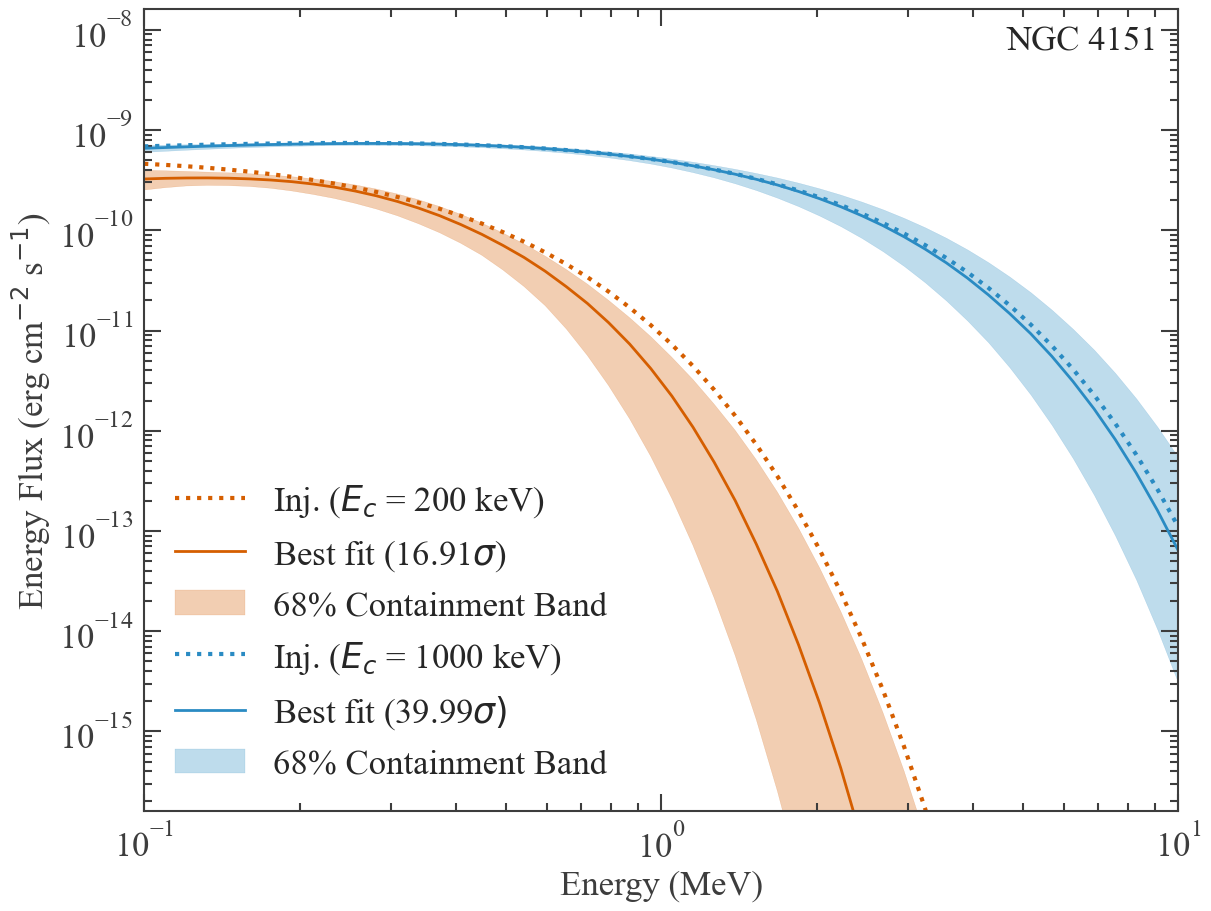

In [22]:
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

Sigma = np.sqrt(TS)
Sigma_ec1000 = np.sqrt(TS_ec1000)

# # NGC 4151
text = f'NGC 4151'

ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_inj, color = '#D55E00', ls = ":", lw=3, label = "Inj. ($E_c$ = 200 keV)")
ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_median, color = '#D55E00', label = f"Best fit ({Sigma:.2f}$\sigma$)")
ax.fill_between(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_lo, SED_KEV_TO_ERG * energy * energy *flux_hi, alpha = .3, color = '#D55E00', label = "68% Containment Band")

ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_inj_ec1000, color = '#2A8BC3', ls = ":", lw=3, label = "Inj. ($E_c$ = 1000 keV)")
ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_median_ec1000, color = '#2A8BC3', label = f"Best fit ({Sigma_ec1000:.2f}$\sigma)$")
ax.fill_between(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_lo_ec1000, SED_KEV_TO_ERG * energy * energy *flux_hi_ec1000, alpha = .3, color='#2A8BC3', label = "68% Containment Band")

ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_ThModel_TH_Fit_200_1000_24Months.pdf"

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(1e-7 * SED_KEV_TO_ERG, 10 * SED_KEV_TO_ERG)

ax.set_xlim((100) * KEV_TO_MEV, (10000) * KEV_TO_MEV)

# ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 5, 10]))
# ax.xaxis.set_major_formatter(
#     mticker.FixedFormatter(["0.1", "5", "10"])
# )

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (erg cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# plt.savefig(save_path)

## Thermal SED (COSI and BAT)

This extracts bin-by-bin SED points from the thermal joint fit. The COSI helper keeps the existing measured-energy-bin workflow, and the BAT helper repeats the same one-free-normalization method over the BAT channels used in the joint fit. In every bin the photon index is frozen to the global-fit value; `xc` is also frozen by default because a single band does not constrain the cutoff reliably. The BAT effective-area correction is fixed to the joint-fit value so the per-bin fit is driven by `K`, matching the COSI nuisance-parameter treatment used below.


In [23]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter
def _get_single_source_name(model):
    source_names = [
        name
        for name, child in getattr(model, '_children', {}).items()
        if hasattr(child, 'spectrum')
    ]

    if len(source_names) != 1:
        raise ValueError(f'Expected one source in optimized model, found {source_names}.')

    return source_names[0]


def _get_cutoff_powerlaw_shape(global_results, source_name=None):
    optimized_model = global_results.optimized_model
    if source_name is None:
        source_name = _get_single_source_name(optimized_model)

    return optimized_model[source_name].spectrum.main.Cutoff_powerlaw, source_name


def build_thermal_sed_model(global_results, freeze_cutoff=True, source_name=None):
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)

    spectrum = Cutoff_powerlaw()
    spectrum.K.value = best_fit_shape.K.value
    spectrum.piv.value = best_fit_shape.piv.value
    spectrum.xc.value = best_fit_shape.xc.value
    spectrum.index.value = best_fit_shape.index.value

    spectrum.K.unit = best_fit_shape.K.unit
    spectrum.piv.unit = best_fit_shape.piv.unit
    spectrum.xc.unit = best_fit_shape.xc.unit

    spectrum.K.min_value = max(best_fit_shape.K.value * 1e-3, 1e-12)
    spectrum.K.max_value = best_fit_shape.K.value * 1e3
    spectrum.index.fix = True
    spectrum.xc.fix = freeze_cutoff

    source = PointSource(source_name, l=l, b=b, spectral_shape=spectrum)
    return Model(source)


def _hist_sum(hist):
    contents = hist.contents
    if hasattr(contents, 'todense'):
        contents = contents.todense()
    if hasattr(contents, 'value'):
        contents = contents.value
    return float(np.asarray(contents).sum())


def _integrate_energy_flux(shape, e_min, e_max, n_points=256):
    energy_grid = np.geomspace(e_min, e_max, n_points)
    photon_flux = np.asarray([float(shape.evaluate_at(energy)) for energy in energy_grid])
    trapezoid = getattr(np, 'trapezoid', None)
    if trapezoid is None:
        trapezoid = np.trapz
    return float(trapezoid(energy_grid * photon_flux, energy_grid))


def _extract_profile_error(errors, suffix):
    if hasattr(errors, 'index'):
        for parameter_path in errors.index:
            if str(parameter_path).endswith(suffix):
                row = errors.loc[parameter_path]
                return float(row['negative_error']), float(row['positive_error'])
        return None

    for parameter_path, interval in errors.items():
        if str(parameter_path).endswith(suffix):
            return interval
    return None


def _get_global_background_scale(global_results, default=1.0):
    try:
        results_frame = global_results.get_data_frame()
    except Exception:
        return float(default)

    for parameter_path in results_frame.index:
        if str(parameter_path).startswith('background_'):
            return float(results_frame.loc[parameter_path, 'value'])

    return float(default)


def _run_joint_likelihood_fit(joint_likelihood):
    fit_status = 'covariance'
    try:
        joint_likelihood.fit(quiet=True)
    except Exception as exc:
        fit_status = f'no-covariance fallback ({type(exc).__name__})'
        joint_likelihood.fit(quiet=True, compute_covariance=False)
    return fit_status


def _get_joint_likelihood_statistic(joint_likelihood):
    statistic_frame = joint_likelihood.results.get_statistic_frame()

    if '-log(likelihood)' in statistic_frame.columns:
        statistic_column = statistic_frame['-log(likelihood)']
    else:
        numeric_frame = statistic_frame.select_dtypes(include=[np.number])
        if numeric_frame.empty:
            raise ValueError(f'No numeric statistic columns found in {list(statistic_frame.columns)}.')
        statistic_column = numeric_frame.iloc[:, 0]

    if 'total' in statistic_column.index:
        return float(statistic_column.loc['total'])

    return float(statistic_column.sum())


def _ts_to_sigma(ts_value):
    if not np.isfinite(ts_value) or ts_value <= 0:
        return 0.0

    return float(np.sqrt(ts_value))


def _build_null_sed_model(
    global_results,
    source_name,
    freeze_cutoff=True,
    null_k_value=1e-30,
):
    null_model = build_thermal_sed_model(
        global_results,
        freeze_cutoff=freeze_cutoff,
        source_name=source_name,
    )
    null_shape = null_model[source_name].spectrum.main.Cutoff_powerlaw
    null_k_value = max(float(null_k_value), np.finfo(float).tiny)
    null_k_min = max(null_k_value * 0.1, np.finfo(float).tiny)
    null_shape.K.min_value = min(float(null_shape.K.min_value or null_k_min), null_k_min)
    null_shape.K.value = null_k_value
    null_shape.K.fix = True

    return null_model


def _make_minuit_with_ftol(minuit_ftol):
    if minuit_ftol is None:
        return None

    minuit = LocalMinimization('minuit')
    minuit.setup(ftol=float(minuit_ftol))

    return minuit


def _hits_lower_bound(value, lower_bound):
    if lower_bound is None or not np.isfinite(lower_bound):
        return False

    atol = max(1e-18, abs(float(lower_bound)) * 1e-6)
    return bool(np.isclose(float(value), float(lower_bound), rtol=1e-3, atol=atol))


def _interpolate_profile_crossing(x1, y1, x2, y2, target):
    if np.isclose(y1, y2):
        return float(0.5 * (x1 + x2))

    fraction = float((target - y1) / (y2 - y1))
    fraction = float(np.clip(fraction, 0.0, 1.0))

    if x1 > 0 and x2 > 0:
        return float(np.exp(np.log(x1) + fraction * (np.log(x2) - np.log(x1))))

    return float(x1 + fraction * (x2 - x1))


def _find_profile_crossing(x_values, delta_ts, threshold, side):
    if len(x_values) == 0:
        return None

    minimum_index = int(np.nanargmin(delta_ts))

    if side == 'left':
        for index in range(minimum_index - 1, -1, -1):
            y1 = float(delta_ts[index])
            y2 = float(delta_ts[index + 1])
            if np.isnan(y1) or np.isnan(y2):
                continue
            if np.isclose(y1, threshold):
                return float(x_values[index])
            if (y1 - threshold) * (y2 - threshold) <= 0:
                return _interpolate_profile_crossing(
                    float(x_values[index]),
                    y1,
                    float(x_values[index + 1]),
                    y2,
                    threshold,
                )
        return None

    for index in range(minimum_index, len(x_values) - 1):
        y1 = float(delta_ts[index])
        y2 = float(delta_ts[index + 1])
        if np.isnan(y1) or np.isnan(y2):
            continue
        if np.isclose(y2, threshold):
            return float(x_values[index + 1])
        if (y1 - threshold) * (y2 - threshold) <= 0:
            return _interpolate_profile_crossing(
                float(x_values[index]),
                y1,
                float(x_values[index + 1]),
                y2,
                threshold,
            )

    return None


def _manual_k_profile_interval(
    joint_likelihood,
    parameter_path,
    center_value,
    lower_bound,
    upper_bound,
    n_steps=61,
    target_delta_ts=1.0,
    max_expansions=12,
    scan_expand_factor=1e2,
):
    if center_value <= 0:
        raise ValueError('Manual K profiling requires a positive best-fit normalization.')

    tiny_positive = float(np.finfo(float).tiny)
    scan_min = max(float(lower_bound), tiny_positive)
    scan_max = float(upper_bound) if np.isfinite(upper_bound) else float(center_value) * 1e6

    if not np.isfinite(scan_max) or scan_max <= scan_min:
        raise ValueError('Invalid K scan bounds for manual profiling.')

    import matplotlib.pyplot as plt

    left_crossing = None
    right_crossing = None

    for _ in range(max_expansions + 1):
        x_values, _, profile_values, profile_figure = joint_likelihood.get_contours(
            parameter_path,
            param_1_minimum=float(scan_min),
            param_1_maximum=float(scan_max),
            param_1_n_steps=int(n_steps),
            progress=False,
            log=(True,),
        )
        plt.close(profile_figure)

        x_values = np.asarray(x_values, dtype=float)
        profile_values = np.asarray(profile_values, dtype=float)
        delta_ts = 2.0 * (profile_values - np.nanmin(profile_values))
        minimum_index = int(np.nanargmin(delta_ts))

        left_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'left')
        right_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'right')

        if left_crossing is not None and right_crossing is not None:
            status = f'manual K profile ok ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
            return float(left_crossing), float(right_crossing), status

        expanded = False

        if left_crossing is None and minimum_index > 0 and delta_ts[0] < target_delta_ts and scan_min > lower_bound:
            new_scan_min = max(float(lower_bound), float(scan_min) / scan_expand_factor)
            if new_scan_min < scan_min:
                scan_min = new_scan_min
                expanded = True

        if right_crossing is None and minimum_index < (len(x_values) - 1) and delta_ts[-1] < target_delta_ts and scan_max < upper_bound:
            new_scan_max = min(float(upper_bound), float(scan_max) * scan_expand_factor)
            if new_scan_max > scan_max:
                scan_max = new_scan_max
                expanded = True

        if not expanded:
            break

    status = f'manual K profile incomplete ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
    return left_crossing, right_crossing, status


def fit_thermal_cosi_sed(
    global_results,
    data_hist,
    bkg_hist,
    dr_path,
    sc_orientation,
    n_sed_bins=5,
    freeze_cutoff=True,
    freeze_background=False,
    background_scale_value=None,
    minuit_ftol=None,
    error_estimation='minos_then_manual',
    manual_k_profile_points=61,
    manual_one_sided_mode='upper_limit',
    relax_k_lower_bound=True,
    energy_min_keV=200,
    energy_max_keV=5000,
    scan_expand_factor=1e2,
):
    threeML_config.point_source.integrate_flux_method = 'trapz'

    em_edges = data_hist.axes['Em'].edges.to_value(u.keV)
    native_em_bins = np.flatnonzero(
        (em_edges[:-1] >= energy_min_keV) & (em_edges[1:] <= energy_max_keV)
    )

    if len(native_em_bins) == 0:
        raise ValueError(
            f'No native Em bins are fully contained in {energy_min_keV}-{energy_max_keV} keV.'
        )

    def _split_last_group_remainder(arr, n_groups):
        arr = np.asarray(arr)
        if len(arr) < n_groups:
            raise ValueError(f"Need at least {n_groups} native bins, got {len(arr)}.")

        sizes = [1] * (n_groups - 1)
        sizes.append(len(arr) - (n_groups - 1))

        groups = []
        start = 0
        for size in sizes:
            groups.append(arr[start:start + size])
            start += size

        return groups

    grouped_bins = _split_last_group_remainder(native_em_bins, n_sed_bins)

    sed_rows = []
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results)
    frozen_index = best_fit_shape.index.value
    frozen_cutoff = best_fit_shape.xc.value
    global_k = float(best_fit_shape.K.value)
    global_background_scale = _get_global_background_scale(global_results, default=1.0)

    if background_scale_value is not None:
        background_scale_value = float(background_scale_value)

    for sed_bin_index, group in enumerate(grouped_bins, start=1):
        em_slice = slice(int(group[0]), int(group[-1]) + 1)
        e_min = float(em_edges[group[0]])
        e_max = float(em_edges[group[-1] + 1])
        e_ref = float(np.sqrt(e_min * e_max))
        data_counts = _hist_sum(data_hist.slice[{'Em': em_slice}])
        background_counts = _hist_sum(bkg_hist.slice[{'Em': em_slice}])

        dataset_name = f'cosi_sed_bin_{sed_bin_index}'

        bin_cosi = EnergyRangeCOSIPlugin(
            name=dataset_name,
            dr=dr_path,
            data=data_hist,
            bkg=bkg_hist,
            sc_orientation=sc_orientation,
            em_slice=em_slice,
            nuisance_param=make_cosi_background_parameter(dataset_name),
            background_pseudocount=BACKGROUND_PSEUDOCOUNT,
            earth_occ=True,
        )

        background_parameter = bin_cosi.nuisance_parameters[f'background_{dataset_name}']

        if freeze_background:
            if background_scale_value is None:
                background_parameter.value = global_background_scale
            else:
                background_parameter.value = background_scale_value
            background_parameter.fix = True
        else:
            background_parameter.fix = False
            if background_scale_value is not None:
                background_parameter.value = background_scale_value

        bin_model = build_thermal_sed_model(global_results, freeze_cutoff=freeze_cutoff, source_name=source_name)
        bin_like = JointLikelihood(bin_model, DataList(bin_cosi), verbose=False)

        bin_minuit = _make_minuit_with_ftol(minuit_ftol)
        if bin_minuit is not None:
            bin_like.set_minimizer(bin_minuit)

        # threeML can reject every covariance sample in weak bins and then crash while building the summary table.
        fit_status = _run_joint_likelihood_fit(bin_like)

        bin_results = bin_like.results
        fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
        k_value = float(fit_shape.K.value)
        k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
        k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
        k_lower_bound_relaxed = False

        if relax_k_lower_bound and _hits_lower_bound(k_value, k_min):
            relaxed_k_min = max(k_min * 1e-2, 1e-18)
            if relaxed_k_min < k_min:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.min_value = relaxed_k_min
                retry_status = _run_joint_likelihood_fit(bin_like)
                fit_status = f'{fit_status}; relaxed K min to {relaxed_k_min:.3e}; retry={retry_status}'
                bin_results = bin_like.results
                fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
                k_value = float(fit_shape.K.value)
                k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
                k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
                k_lower_bound_relaxed = True

        joint_statistic = _get_joint_likelihood_statistic(bin_like)

        null_dataset_name = f'{dataset_name}_null'
        null_cosi = EnergyRangeCOSIPlugin(
            name=null_dataset_name,
            dr=dr_path,
            data=data_hist,
            bkg=bkg_hist,
            sc_orientation=sc_orientation,
            em_slice=em_slice,
            nuisance_param=make_cosi_background_parameter(null_dataset_name),
            background_pseudocount=BACKGROUND_PSEUDOCOUNT,
            earth_occ=True,
        )

        null_background_parameter = null_cosi.nuisance_parameters[f'background_{null_dataset_name}']
        if freeze_background:
            if background_scale_value is None:
                null_background_parameter.value = global_background_scale
            else:
                null_background_parameter.value = background_scale_value
            null_background_parameter.fix = True
        else:
            null_background_parameter.fix = False
            if background_scale_value is not None:
                null_background_parameter.value = background_scale_value
            else:
                null_background_parameter.value = float(background_parameter.value)

        null_model = _build_null_sed_model(
            global_results,
            source_name=source_name,
            freeze_cutoff=freeze_cutoff,
        )
        null_like = JointLikelihood(null_model, DataList(null_cosi), verbose=False)

        null_minuit = _make_minuit_with_ftol(minuit_ftol)
        if null_minuit is not None:
            null_like.set_minimizer(null_minuit)

        null_fit_status = _run_joint_likelihood_fit(null_like)
        joint_null_statistic = _get_joint_likelihood_statistic(null_like)
        ts_value_raw = 2.0 * (joint_null_statistic - joint_statistic)
        ts_value = max(0.0, float(ts_value_raw))
        sigma = _ts_to_sigma(ts_value)

        k_lo = k_value
        k_hi = k_value
        profile_error_status = 'not available'
        error_source = 'profile'
        has_two_sided_error = False

        run_manual_profile = error_estimation == 'manual_profile'

        if error_estimation in ('minos', 'minos_then_manual'):
            try:
                profile_errors = bin_like.get_errors(quiet=True)
                k_errors = _extract_profile_error(profile_errors, '.K')
                if k_errors is not None:
                    k_lo = max(k_value + float(k_errors[0]), k_min)
                    k_hi = min(k_value + float(k_errors[1]), k_max)
                    profile_error_status = 'ok'
                    error_source = 'profile'
                    has_two_sided_error = bool(np.isfinite(k_lo) and np.isfinite(k_hi) and (k_hi > k_lo))
                    if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                        run_manual_profile = True
                else:
                    profile_error_status = 'K profile error unavailable'
                    if error_estimation == 'minos_then_manual':
                        run_manual_profile = True
            except Exception as exc:
                profile_error_status = f'{type(exc).__name__}: {exc}'
                error_source = 'profile failed'

                if not _hits_lower_bound(k_value, k_min):
                    try:
                        covariance_errors = bin_results.get_data_frame(error_type='covariance')
                        k_cov_errors = _extract_profile_error(covariance_errors, '.K')
                        if k_cov_errors is not None:
                            cov_lo = max(k_value + float(k_cov_errors[0]), k_min)
                            cov_hi = min(k_value + float(k_cov_errors[1]), k_max)
                            if np.isfinite(cov_lo) and np.isfinite(cov_hi) and (cov_hi > cov_lo):
                                k_lo = cov_lo
                                k_hi = cov_hi
                                profile_error_status = f'covariance fallback ({type(exc).__name__})'
                                error_source = 'covariance fallback'
                                has_two_sided_error = True
                    except Exception:
                        pass

                if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                    run_manual_profile = True

        if run_manual_profile:
            profile_k_max = max(k_max, global_k * 1e6, k_value * 1e6)
            if np.isfinite(profile_k_max) and profile_k_max > k_max:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value = profile_k_max
                k_max = float(bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value)

            k_path = f'{source_name}.spectrum.main.Cutoff_powerlaw.K'
            try:
                profile_k_lo, profile_k_hi, manual_status = _manual_k_profile_interval(
                    bin_like,
                    k_path,
                    k_value,
                    k_min,
                    k_max,
                    n_steps=manual_k_profile_points,
                    max_expansions=12,
                    scan_expand_factor=scan_expand_factor,
                )

                if profile_k_lo is not None and profile_k_hi is not None and profile_k_hi > profile_k_lo:
                    k_lo = max(float(profile_k_lo), k_min)
                    k_hi = min(float(profile_k_hi), k_max)
                    profile_error_status = manual_status
                    error_source = 'manual profile'
                    has_two_sided_error = True
                elif profile_k_hi is not None:
                    k_hi = min(float(profile_k_hi), k_max)
                    if manual_one_sided_mode == 'lower_bound_interval':
                        k_lo = k_min
                        profile_error_status = manual_status.replace('incomplete', 'lower-bound interval')
                        error_source = 'manual lower-bound interval'
                        has_two_sided_error = True
                    else:
                        k_lo = k_value
                        profile_error_status = manual_status.replace('incomplete', 'upper limit')
                        error_source = 'manual upper limit'
                else:
                    profile_error_status = manual_status
                    error_source = 'manual profile incomplete'
            except Exception as exc:
                profile_error_status = f'manual K profile failed ({type(exc).__name__}: {exc})'
                error_source = 'manual profile failed'

        scale_lo = k_lo / k_value if k_value > 0 else 1.0
        scale_hi = k_hi / k_value if k_value > 0 else 1.0
        integrated_flux = _integrate_energy_flux(fit_shape, e_min, e_max)
        sed_flux = float(e_ref**2 * fit_shape.evaluate_at(e_ref))
        background_scale = float(bin_cosi.nuisance_parameters[f'background_{dataset_name}'].value)
        background_is_fixed = bool(background_parameter.fix)
        hit_parameter_bound = bool(np.isclose(k_value, k_min) or (np.isfinite(k_max) and np.isclose(k_value, k_max)))
        is_upper_limit = bool(
            error_source == 'manual upper limit'
            or ((not has_two_sided_error) and _hits_lower_bound(k_value, k_min))
        )

        sed_rows.append(
            {
                'bin_index': sed_bin_index,
                'e_min_keV': e_min,
                'e_max_keV': e_max,
                'e_ref_keV': e_ref,
                'bin_energy_flux_erg_cm2_s': integrated_flux,
                'bin_energy_flux_lo_erg_cm2_s': integrated_flux * scale_lo,
                'bin_energy_flux_hi_erg_cm2_s': integrated_flux * scale_hi,
                'sed_erg_cm2_s': sed_flux,
                'sed_lo_erg_cm2_s': sed_flux * scale_lo,
                'sed_hi_erg_cm2_s': sed_flux * scale_hi,
                'source_K': k_value,
                'source_K_lo': k_lo,
                'source_K_hi': k_hi,
                'source_K_over_global': k_value / global_k if global_k > 0 else np.nan,
                'background_scale': background_scale,
                'background_scale_reference': (
                    global_background_scale if background_scale_value is None else background_scale_value
                ),
                'background_requested_fixed': freeze_background,
                'background_scale_fixed': background_is_fixed,
                'background_released_for_retry': False,
                'data_counts': data_counts,
                'background_counts': background_counts,
                'excess_counts': data_counts - background_counts,
                'joint_statistic': joint_statistic,
                'joint_null_statistic': joint_null_statistic,
                'ts_value_raw': ts_value_raw,
                'ts_value': ts_value,
                'sigma': sigma,
                'null_fit_status': null_fit_status,
                'fit_status': fit_status,
                'profile_error_status': profile_error_status,
                'error_source': error_source,
                'minuit_ftol': minuit_ftol,
                'error_estimation': error_estimation,
                'manual_one_sided_mode': manual_one_sided_mode,
                'k_lower_bound_relaxed': k_lower_bound_relaxed,
                'hit_parameter_bound': hit_parameter_bound,
                'is_upper_limit': is_upper_limit,
                'frozen_index': frozen_index,
                'frozen_cutoff_keV': frozen_cutoff,
            }
        )

    sed_df = pd.DataFrame(sed_rows)
    energy_flux_columns = [
        column for column in sed_df.columns
        if column.endswith("_erg_cm2_s")
    ]
    sed_df[energy_flux_columns] *= SED_KEV_TO_ERG
    return sed_df


def _get_effective_area_scale(global_results, plugin_name='BAT', default=1.0):
    try:
        results_frame = global_results.get_data_frame()
    except Exception:
        return float(default)

    candidates = [f'cons_{plugin_name}']
    for parameter_path in results_frame.index:
        parameter_name = str(parameter_path).split('.')[-1]
        if parameter_name in candidates or parameter_name.startswith(f'cons_{plugin_name}'):
            return float(results_frame.loc[parameter_path, 'value'])

    return float(default)


def _get_ogip_active_channel_bins(observation_path, response_path, active_range):
    probe = OGIPLike(
        '__bat_sed_probe__',
        observation=observation_path,
        response=response_path,
        verbose=False,
    )
    probe.set_active_measurements(active_range)

    active_channel_indices = np.flatnonzero(np.asarray(probe.mask, dtype=bool))
    e_min_active, e_max_active = probe.energy_boundaries

    if len(active_channel_indices) == 0:
        raise ValueError(f'No BAT channels selected by active range {active_range!r}.')

    return [
        {
            'channel_index': int(channel_index),
            'channel_number': int(channel_index + 1),
            'e_min_keV': float(e_min),
            'e_max_keV': float(e_max),
        }
        for channel_index, e_min, e_max in zip(active_channel_indices, e_min_active, e_max_active)
    ]


def _select_single_ogip_channel(plugin, channel_index):
    channel_mask = np.zeros_like(np.asarray(plugin.mask, dtype=bool))
    channel_mask[int(channel_index)] = True
    plugin._mask = channel_mask
    plugin._apply_mask_to_original_vectors()


def fit_thermal_bat_sed(
    global_results,
    observation_path,
    response_path,
    active_range='40-200',
    freeze_cutoff=True,
    freeze_effective_area=True,
    effective_area_value=None,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=201,
    manual_one_sided_mode='lower_bound_interval',
    scan_expand_factor=1e3,
):
    threeML_config.point_source.integrate_flux_method = 'trapz'

    bat_bins = _get_ogip_active_channel_bins(observation_path, response_path, active_range)
    sed_rows = []
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results)
    frozen_index = best_fit_shape.index.value
    frozen_cutoff = best_fit_shape.xc.value
    global_k = float(best_fit_shape.K.value)
    global_effective_area_scale = _get_effective_area_scale(global_results, plugin_name='BAT', default=1.0)

    if effective_area_value is not None:
        effective_area_value = float(effective_area_value)

    for sed_bin_index, bat_bin in enumerate(bat_bins, start=1):
        e_min = bat_bin['e_min_keV']
        e_max = bat_bin['e_max_keV']
        e_ref = float(np.sqrt(e_min * e_max))
        channel_index = bat_bin['channel_index']
        channel_number = bat_bin['channel_number']
        dataset_name = f'bat_sed_bin_{sed_bin_index}'

        bin_bat = OGIPLike(
            dataset_name,
            observation=observation_path,
            response=response_path,
            verbose=False,
        )
        bin_bat.set_active_measurements(active_range)
        _select_single_ogip_channel(bin_bat, channel_index)
        bin_bat.use_effective_area_correction(0.2, 1.8)

        area_parameter = bin_bat.nuisance_parameters[f'cons_{dataset_name}']
        area_reference = global_effective_area_scale if effective_area_value is None else effective_area_value

        if freeze_effective_area:
            bin_bat.fix_effective_area_correction(area_reference)
        else:
            area_parameter.value = area_reference
            area_parameter.fix = False

        bin_model = build_thermal_sed_model(global_results, freeze_cutoff=freeze_cutoff, source_name=source_name)
        bin_like = JointLikelihood(bin_model, DataList(bin_bat), verbose=False)

        bin_minuit = _make_minuit_with_ftol(minuit_ftol)
        if bin_minuit is not None:
            bin_like.set_minimizer(bin_minuit)

        fit_status = _run_joint_likelihood_fit(bin_like)

        bin_results = bin_like.results
        fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
        k_value = float(fit_shape.K.value)
        k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
        k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
        k_lower_bound_relaxed = False

        joint_statistic = _get_joint_likelihood_statistic(bin_like)

        null_dataset_name = f'{dataset_name}_null'
        null_bat = OGIPLike(
            null_dataset_name,
            observation=observation_path,
            response=response_path,
            verbose=False,
        )
        null_bat.set_active_measurements(active_range)
        _select_single_ogip_channel(null_bat, channel_index)
        null_bat.use_effective_area_correction(0.2, 1.8)

        null_area_parameter = null_bat.nuisance_parameters[f'cons_{null_dataset_name}']
        if freeze_effective_area:
            null_bat.fix_effective_area_correction(area_reference)
        else:
            null_area_parameter.value = effective_area_value if effective_area_value is not None else float(area_parameter.value)
            null_area_parameter.fix = False

        null_model = _build_null_sed_model(
            global_results,
            source_name=source_name,
            freeze_cutoff=freeze_cutoff,
        )
        null_like = JointLikelihood(null_model, DataList(null_bat), verbose=False)

        null_minuit = _make_minuit_with_ftol(minuit_ftol)
        if null_minuit is not None:
            null_like.set_minimizer(null_minuit)

        null_fit_status = _run_joint_likelihood_fit(null_like)
        joint_null_statistic = _get_joint_likelihood_statistic(null_like)
        ts_value_raw = 2.0 * (joint_null_statistic - joint_statistic)
        ts_value = max(0.0, float(ts_value_raw))
        sigma = _ts_to_sigma(ts_value)

        k_lo = k_value
        k_hi = k_value
        profile_error_status = 'not available'
        error_source = 'profile'
        has_two_sided_error = False

        run_manual_profile = error_estimation == 'manual_profile'

        if error_estimation in ('minos', 'minos_then_manual'):
            try:
                profile_errors = bin_like.get_errors(quiet=True)
                k_errors = _extract_profile_error(profile_errors, '.K')
                if k_errors is not None:
                    k_lo = max(k_value + float(k_errors[0]), k_min)
                    k_hi = min(k_value + float(k_errors[1]), k_max)
                    profile_error_status = 'ok'
                    error_source = 'profile'
                    has_two_sided_error = bool(np.isfinite(k_lo) and np.isfinite(k_hi) and (k_hi > k_lo))
                    if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                        run_manual_profile = True
                else:
                    profile_error_status = 'K profile error unavailable'
                    if error_estimation == 'minos_then_manual':
                        run_manual_profile = True
            except Exception as exc:
                profile_error_status = f'{type(exc).__name__}: {exc}'
                error_source = 'profile failed'

                if not _hits_lower_bound(k_value, k_min):
                    try:
                        covariance_errors = bin_results.get_data_frame(error_type='covariance')
                        k_cov_errors = _extract_profile_error(covariance_errors, '.K')
                        if k_cov_errors is not None:
                            cov_lo = max(k_value + float(k_cov_errors[0]), k_min)
                            cov_hi = min(k_value + float(k_cov_errors[1]), k_max)
                            if np.isfinite(cov_lo) and np.isfinite(cov_hi) and (cov_hi > cov_lo):
                                k_lo = cov_lo
                                k_hi = cov_hi
                                profile_error_status = f'covariance fallback ({type(exc).__name__})'
                                error_source = 'covariance fallback'
                                has_two_sided_error = True
                    except Exception:
                        pass

                if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                    run_manual_profile = True

        if run_manual_profile:
            profile_k_max = max(k_max, global_k * 1e6, k_value * 1e6)
            if np.isfinite(profile_k_max) and profile_k_max > k_max:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value = profile_k_max
                k_max = float(bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value)

            k_path = f'{source_name}.spectrum.main.Cutoff_powerlaw.K'
            try:
                profile_k_lo, profile_k_hi, manual_status = _manual_k_profile_interval(
                    bin_like,
                    k_path,
                    k_value,
                    k_min,
                    k_max,
                    n_steps=manual_k_profile_points,
                    max_expansions=12,
                    scan_expand_factor=scan_expand_factor,
                )

                if profile_k_lo is not None and profile_k_hi is not None and profile_k_hi > profile_k_lo:
                    k_lo = max(float(profile_k_lo), k_min)
                    k_hi = min(float(profile_k_hi), k_max)
                    profile_error_status = manual_status
                    error_source = 'manual profile'
                    has_two_sided_error = True
                elif profile_k_hi is not None:
                    k_hi = min(float(profile_k_hi), k_max)
                    if manual_one_sided_mode == 'lower_bound_interval':
                        k_lo = k_min
                        profile_error_status = manual_status.replace('incomplete', 'lower-bound interval')
                        error_source = 'manual lower-bound interval'
                        has_two_sided_error = True
                    else:
                        k_lo = k_value
                        profile_error_status = manual_status.replace('incomplete', 'upper limit')
                        error_source = 'manual upper limit'
                else:
                    profile_error_status = manual_status
                    error_source = 'manual profile incomplete'
            except Exception as exc:
                profile_error_status = f'manual K profile failed ({type(exc).__name__}: {exc})'
                error_source = 'manual profile failed'

        scale_lo = k_lo / k_value if k_value > 0 else 1.0
        scale_hi = k_hi / k_value if k_value > 0 else 1.0
        integrated_flux = _integrate_energy_flux(fit_shape, e_min, e_max)
        sed_flux = float(e_ref**2 * fit_shape.evaluate_at(e_ref))
        effective_area_scale = float(area_parameter.value)
        effective_area_is_fixed = bool(area_parameter.fix)
        hit_parameter_bound = bool(np.isclose(k_value, k_min) or (np.isfinite(k_max) and np.isclose(k_value, k_max)))
        is_upper_limit = bool(
            error_source == 'manual upper limit'
            or ((not has_two_sided_error) and _hits_lower_bound(k_value, k_min))
        )
        observed_counts = float(np.asarray(bin_bat._current_observed_counts).sum())
        current_background_counts = getattr(bin_bat, '_current_background_counts', None)
        if current_background_counts is None:
            background_counts = 0.0
        else:
            background_counts = float(np.asarray(current_background_counts).sum())

        sed_rows.append(
            {
                'instrument': 'BAT',
                'bin_index': sed_bin_index,
                'channel_index': channel_index,
                'channel_number': channel_number,
                'active_range': active_range,
                'e_min_keV': e_min,
                'e_max_keV': e_max,
                'e_ref_keV': e_ref,
                'bin_energy_flux_erg_cm2_s': integrated_flux,
                'bin_energy_flux_lo_erg_cm2_s': integrated_flux * scale_lo,
                'bin_energy_flux_hi_erg_cm2_s': integrated_flux * scale_hi,
                'sed_erg_cm2_s': sed_flux,
                'sed_lo_erg_cm2_s': sed_flux * scale_lo,
                'sed_hi_erg_cm2_s': sed_flux * scale_hi,
                'source_K': k_value,
                'source_K_lo': k_lo,
                'source_K_hi': k_hi,
                'source_K_over_global': k_value / global_k if global_k > 0 else np.nan,
                'effective_area_scale': effective_area_scale,
                'effective_area_scale_reference': area_reference,
                'effective_area_requested_fixed': freeze_effective_area,
                'effective_area_scale_fixed': effective_area_is_fixed,
                'data_counts': observed_counts,
                'background_counts': background_counts,
                'excess_counts': observed_counts - background_counts,
                'joint_statistic': joint_statistic,
                'joint_null_statistic': joint_null_statistic,
                'ts_value_raw': ts_value_raw,
                'ts_value': ts_value,
                'sigma': sigma,
                'null_fit_status': null_fit_status,
                'fit_status': fit_status,
                'profile_error_status': profile_error_status,
                'error_source': error_source,
                'minuit_ftol': minuit_ftol,
                'error_estimation': error_estimation,
                'manual_one_sided_mode': manual_one_sided_mode,
                'k_lower_bound_relaxed': k_lower_bound_relaxed,
                'hit_parameter_bound': hit_parameter_bound,
                'is_upper_limit': is_upper_limit,
                'frozen_index': frozen_index,
                'frozen_cutoff_keV': frozen_cutoff,
            }
        )

    sed_df = pd.DataFrame(sed_rows)
    energy_flux_columns = [
        column for column in sed_df.columns
        if column.endswith("_erg_cm2_s")
    ]
    sed_df[energy_flux_columns] *= SED_KEV_TO_ERG
    return sed_df



In [24]:
n_thermal_sed_bins = 8

# # Manual Scan
# thermal_cosi_sed_df = fit_thermal_cosi_sed(
#     global_results=results_sed,
#     data_hist=data_sed_hist,
#     bkg_hist=bkg_sed_hist,
#     dr_path=dr,
#     sc_orientation=sc_orientation,
#     n_sed_bins=n_thermal_sed_bins,
#     freeze_cutoff=True,
#     freeze_background=False,
#     minuit_ftol=1e-3,
#     error_estimation='manual_profile',
#     manual_k_profile_points=61,
#     energy_min_keV=200,
#     energy_max_keV=5000,
# )

thermal_cosi_sed_df = fit_thermal_cosi_sed(
    global_results=results_sed,
    data_hist=data_sed_hist,
    bkg_hist=bkg_sed_hist,
    dr_path=dr,
    sc_orientation=sc_orientation,
    n_sed_bins=n_thermal_sed_bins,
    freeze_cutoff=True,
    freeze_background=True,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=201,
    manual_one_sided_mode='lower_bound_interval',
    energy_min_keV=100,
    energy_max_keV=10000,
    scan_expand_factor=1e6,
)


display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "e_min_keV",
            "e_max_keV",
            "e_ref_keV",
            "bin_energy_flux_erg_cm2_s",
            "bin_energy_flux_lo_erg_cm2_s",
            "bin_energy_flux_hi_erg_cm2_s",
        ]
    ]
)

display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "source_K",
            "source_K_lo",
            "source_K_hi",
            "source_K_over_global",
            "background_scale",
            "background_scale_reference",
            "background_requested_fixed",
            "background_scale_fixed",
            "background_released_for_retry",
            "data_counts",
            "background_counts",
            "excess_counts",
            "joint_statistic",
            "joint_null_statistic",
            "ts_value",
            "sigma",
            "fit_status",
            "null_fit_status",
            "profile_error_status",
            "error_source",
            "minuit_ftol",
            "error_estimation",
            "k_lower_bound_relaxed",
            "hit_parameter_bound",
            "is_upper_limit",
        ]
    ]
)


14:14:35 INFO      set the minimizer to minuit                                             ]8;id=181268;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=913005;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=923142;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=200322;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=393770;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=890691;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=201221;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=844637;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=658849;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=997906;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

         INFO      set the minimizer to minuit                                             ]8;id=639562;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=559073;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=35687;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=857432;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=133519;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=763504;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

,bin_index,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_erg_cm2_s,bin_energy_flux_lo_erg_cm2_s,bin_energy_flux_hi_erg_cm2_s
0,1,100.000,158.489,125.892414,1.686884e-10,1.475339e-10,1.899045e-10
1,2,158.489,251.189,199.526172,1.440308e-10,1.315657e-10,1.565877e-10
2,3,251.189,398.107,316.227923,1.058456e-10,9.372561e-11,1.179826e-10
3,4,398.107,630.957,501.186989,2.283183e-11,7.233665e-12,3.849557e-11
4,5,630.957,1000.000,794.328018,4.541636e-11,2.324116e-11,6.761780e-11
5,6,1000.000,1584.890,1258.924144,1.830307e-15,3.855562e-16,2.268938e-11
6,7,1584.890,2511.890,1995.261723,1.643378e-17,3.585119e-18,1.819864e-11
7,8,2511.890,10000.000,5011.875896,2.068180e-15,2.068192e-21,2.068192e-15


,bin_index,source_K,source_K_lo,source_K_hi,source_K_over_global,background_scale,background_scale_reference,background_requested_fixed,background_scale_fixed,background_released_for_retry,data_counts,background_counts,excess_counts,joint_statistic,joint_null_statistic,ts_value,sigma,fit_status,null_fit_status,profile_error_status,error_source,minuit_ftol,error_estimation,k_lower_bound_relaxed,hit_parameter_bound,is_upper_limit
0,1,2.707739e-05,2.368172e-05,0.000030,1.042456,25.570649,25.570649,True,True,False,3385652.0,3371214.0,14438.0,-1.551691e+07,-1.551684e+07,143.819366,11.992471,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
1,2,2.498452e-05,2.282223e-05,0.000027,0.961883,25.570649,25.570649,True,True,False,6806597.0,6783193.0,23404.0,-3.499737e+07,-3.499730e+07,133.286558,11.544980,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
2,3,2.783367e-05,2.464655e-05,0.000031,1.071573,25.570649,25.570649,True,True,False,5228700.0,5215451.0,13249.0,-2.497700e+07,-2.497694e+07,117.201478,10.825963,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
3,4,1.528626e-05,4.843048e-06,0.000026,0.588508,25.570649,25.570649,True,True,False,3543047.0,3540103.0,2944.0,-1.517171e+07,-1.517171e+07,2.141309,1.463321,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
4,5,1.694828e-04,8.673038e-05,0.000252,6.524945,25.570649,25.570649,True,True,False,2339388.0,2337742.0,1646.0,-9.024023e+06,-9.024020e+06,4.200886,2.049606,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
5,6,1.233062e-07,2.597460e-08,0.001529,0.004747,25.570649,25.570649,True,True,False,1869466.0,1871494.0,-2028.0,-6.808260e+06,-6.808260e+06,0.000000,0.000000,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
6,7,1.190647e-07,2.597460e-08,0.131851,0.004584,25.570649,25.570649,True,True,False,1266096.0,1267750.0,-1654.0,-4.184100e+06,-4.184100e+06,0.000000,0.000000,covariance,covariance,manual K profile lower-bound interval (201 poi...,manual lower-bound interval,0.01,minos_then_manual,False,False,False
7,8,2.597444e-02,2.597460e-08,0.025975,999.993987,25.570649,25.570649,True,True,False,684440.0,684087.0,353.0,-1.570728e+06,-1.570728e+06,0.000056,0.007490,covariance,covariance,ok,profile,0.01,minos_then_manual,False,True,False


In [25]:
n_thermal_sed_bins = 10

# # Manual Scan
# thermal_cosi_sed_df_ec1000 = fit_thermal_cosi_sed(
#     global_results=results_sed_ec1000,
#     data_hist=data_sed_hist,
#     bkg_hist=bkg_sed_hist,
#     dr_path=dr,
#     sc_orientation=sc_orientation,
#     n_sed_bins=n_thermal_sed_bins,
#     freeze_cutoff=True,
#     freeze_background=False,
#     minuit_ftol=1e-3,
#     error_estimation='manual_profile',
#     manual_k_profile_points=61,
#     manual_one_sided_mode='lower_bound_interval',
#     energy_min_keV=200,
#     energy_max_keV=5000,
# )

thermal_cosi_sed_df_ec1000 = fit_thermal_cosi_sed(
    global_results=results_sed_ec1000,
    data_hist=data_sed_ec1000_hist,
    bkg_hist=bkg_sed_ec1000_hist,
    dr_path=dr,
    sc_orientation=sc_orientation,
    n_sed_bins=n_thermal_sed_bins,
    freeze_cutoff=True,
    freeze_background=True,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=81,
    manual_one_sided_mode='lower_bound_interval',
    energy_min_keV=100,
    energy_max_keV=10000,
    scan_expand_factor=1e3,
)

display(
    thermal_cosi_sed_df_ec1000[
        [
            "bin_index",
            "e_min_keV",
            "e_max_keV",
            "e_ref_keV",
            "bin_energy_flux_erg_cm2_s",
            "bin_energy_flux_lo_erg_cm2_s",
            "bin_energy_flux_hi_erg_cm2_s",
        ]
    ]
)

display(
    thermal_cosi_sed_df_ec1000[
        [
            "bin_index",
            "source_K",
            "source_K_lo",
            "source_K_hi",
            "source_K_over_global",
            "background_scale",
            "background_scale_reference",
            "background_requested_fixed",
            "background_scale_fixed",
            "background_released_for_retry",
            "data_counts",
            "background_counts",
            "excess_counts",
            "joint_statistic",
            "joint_null_statistic",
            "ts_value",
            "sigma",
            "fit_status",
            "null_fit_status",
            "profile_error_status",
            "error_source",
            "minuit_ftol",
            "error_estimation",
            "manual_one_sided_mode",
            "k_lower_bound_relaxed",
            "hit_parameter_bound",
            "is_upper_limit",
        ]
    ]
)

# SED-only 24-month calculations. Run this section only after inspecting the
# 3- and 24-month global-fit tables, TS values, and combined text summary above.
thermal_cosi_sed_df_24m = fit_thermal_cosi_sed(
    global_results=results_sed_24m,
    data_hist=data_sed_hist_24m,
    bkg_hist=bkg_sed_hist_24m,
    dr_path=dr,
    sc_orientation=sc_orientation_24m,
    n_sed_bins=8,
    freeze_cutoff=True,
    freeze_background=True,
    minuit_ftol=1e-2,
    error_estimation="minos_then_manual",
    manual_k_profile_points=201,
    manual_one_sided_mode="lower_bound_interval",
    energy_min_keV=100,
    energy_max_keV=10000,
    scan_expand_factor=1e6,
)

thermal_cosi_sed_df_ec1000_24m = fit_thermal_cosi_sed(
    global_results=results_sed_ec1000_24m,
    data_hist=data_sed_ec1000_hist_24m,
    bkg_hist=bkg_sed_ec1000_hist_24m,
    dr_path=dr,
    sc_orientation=sc_orientation_24m,
    n_sed_bins=10,
    freeze_cutoff=True,
    freeze_background=True,
    minuit_ftol=1e-2,
    error_estimation="minos_then_manual",
    manual_k_profile_points=81,
    manual_one_sided_mode="lower_bound_interval",
    energy_min_keV=100,
    energy_max_keV=10000,
    scan_expand_factor=1e3,
)

display(
    thermal_cosi_sed_df_24m[
        ["bin_index", "e_min_keV", "e_max_keV", "ts_value", "sigma", "fit_status"]
    ]
)
display(
    thermal_cosi_sed_df_ec1000_24m[
        ["bin_index", "e_min_keV", "e_max_keV", "ts_value", "sigma", "fit_status"]
    ]
)


         INFO      set the minimizer to minuit                                             ]8;id=476896;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=228165;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=831278;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=108703;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:14:40 INFO      set the minimizer to minuit                                             ]8;id=453775;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=849051;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=686338;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=227070;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=522103;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=948550;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

         INFO      set the minimizer to minuit                                             ]8;id=840836;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=400364;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=205964;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=661563;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=647029;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=372163;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

,bin_index,e_min_keV,e_max_keV,ts_value,sigma,fit_status
0,1,100.000,158.489,1071.682145,32.736557,covariance
1,2,158.489,251.189,1511.215290,38.874353,covariance
2,3,251.189,398.107,886.153931,29.768338,covariance
3,4,398.107,630.957,103.448281,10.170953,covariance
4,5,630.957,1000.000,4.641804,2.154485,covariance
5,6,1000.000,1584.890,1.152886,1.073725,covariance
6,7,1584.890,2511.890,0.048885,0.221099,covariance
7,8,2511.890,10000.000,0.000000,0.000000,covariance


,bin_index,e_min_keV,e_max_keV,ts_value,sigma,fit_status
0,1,100.000,158.489,2904.735754,53.895601,covariance
1,2,158.489,251.189,6826.155043,82.620549,covariance
2,3,251.189,398.107,7697.036480,87.732756,covariance
3,4,398.107,630.957,3685.505489,60.708364,covariance
4,5,630.957,1000.000,1108.698364,33.297122,covariance
5,6,1000.000,1584.890,198.684909,14.095563,covariance
6,7,1584.890,2511.890,160.398091,12.664837,covariance
7,8,2511.890,3981.070,40.046177,6.328205,covariance
8,9,3981.070,6309.570,73.932576,8.598405,covariance
9,10,6309.570,10000.000,0.000000,0.000000,covariance


### Plot A — representative median data set

SED bin values and point/upper-limit decisions come only from the selected representative realization.


Plot A: representative median data set; classification uses its own bin TS.


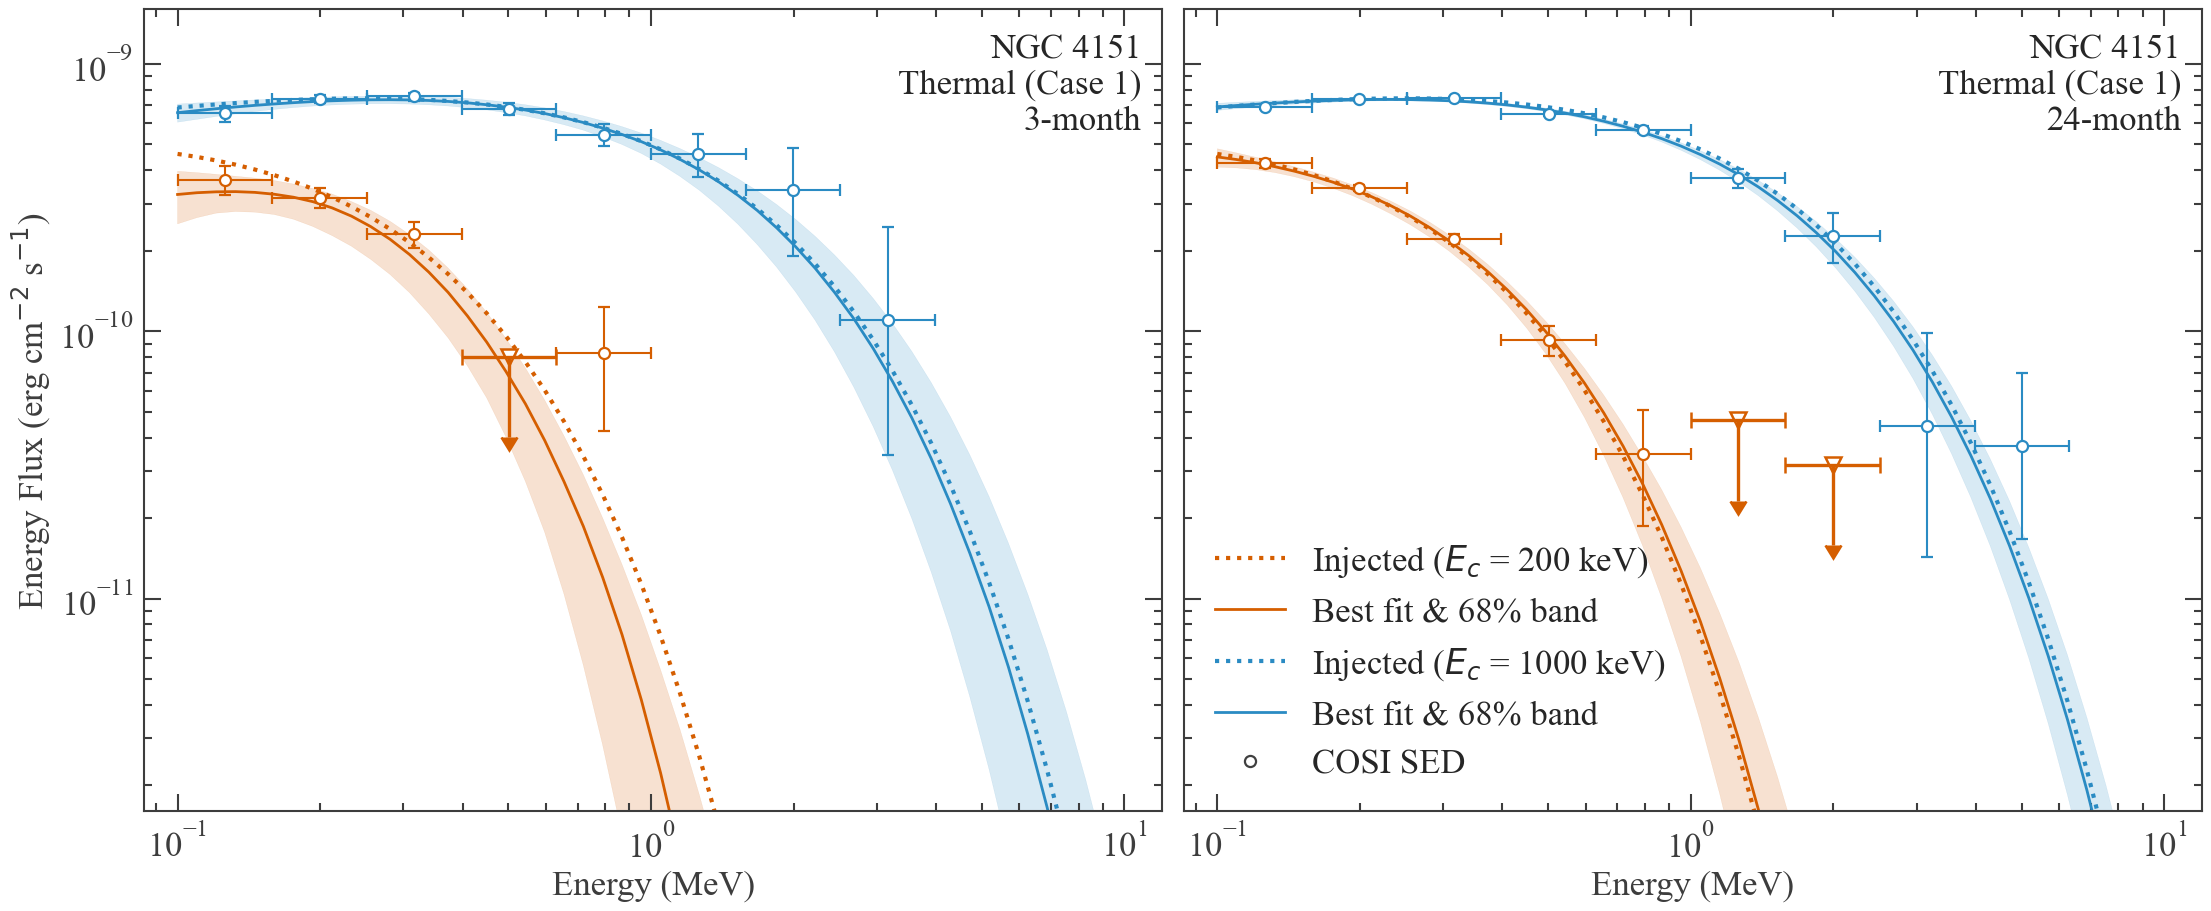

In [26]:
from agn_sed_ensemble import classify_representative_sed

# Plot A uses only the selected representative realization. Its own
# per-bin TS decides detection/upper limit/omission; no 300-seed
# bin-median statistic enters this plot.
representative_thermal_cosi_sed_df_ec1000_24m = classify_representative_sed(thermal_cosi_sed_df_ec1000_24m, detection_ts=4.0)
representative_thermal_cosi_sed_df_24m = classify_representative_sed(thermal_cosi_sed_df_24m, detection_ts=4.0)
representative_thermal_cosi_sed_df_ec1000 = classify_representative_sed(thermal_cosi_sed_df_ec1000, detection_ts=4.0)
representative_thermal_cosi_sed_df = classify_representative_sed(thermal_cosi_sed_df, detection_ts=4.0)

print('Plot A: representative median data set; classification uses its own bin TS.')
FONT_SIZE = 25

plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update(
    {
        "font.weight": "550",
        "axes.titleweight": "550",
        "axes.labelweight": "550",
    }
)

def _make_xerr(df):
    return KEV_TO_MEV * np.vstack(
        [
            df["e_ref_keV"] - df["e_min_keV"],
            df["e_max_keV"] - df["e_ref_keV"],
        ]
    )


def _split_sed_detections(df, ts_threshold=4.0, min_plot_ts=1.0):
    if 'plot_role' in df.columns:
        roles = df['plot_role'].astype(str)
        return (
            df.loc[roles == 'detection'].copy(),
            df.loc[roles == 'upper_limit'].copy(),
        )

    plot_mask = np.ones(len(df), dtype=bool)
    upper_limit_mask = df['is_upper_limit'].copy()

    if 'ts_value' in df.columns:
        plot_mask = df['ts_value'] >= min_plot_ts
        upper_limit_mask = upper_limit_mask | (df['ts_value'] < ts_threshold)

    return (
        df.loc[plot_mask & ~upper_limit_mask].copy(),
        df.loc[plot_mask & upper_limit_mask].copy(),
    )


def _plot_sed_points(ax, det, ul, marker, color, facecolor, label):
    if not det.empty:
        detection_yerr = np.vstack(
            [
                np.maximum(det['sed_erg_cm2_s'] - det['sed_lo_erg_cm2_s'], 0),
                np.maximum(det['sed_hi_erg_cm2_s'] - det['sed_erg_cm2_s'], 0),
            ]
        )

        ax.errorbar(
            det['e_ref_keV'] * KEV_TO_MEV,
            det['sed_erg_cm2_s'],
            xerr=_make_xerr(det),
            yerr=detection_yerr,
            fmt=marker,
            color=color,
            ecolor=color,
            markerfacecolor=facecolor,
            markeredgecolor=color,
            markeredgewidth=1.6,
            elinewidth=1.5,
            capsize=4,
            markersize=8,
            label=label,
        )

    if not ul.empty:
        upper_y = ul['sed_hi_erg_cm2_s'].to_numpy()
        upper_yerr = np.maximum(0.5 * upper_y, np.finfo(float).tiny)

        ax.errorbar(
            ul['e_ref_keV'] * KEV_TO_MEV,
            upper_y,
            xerr=_make_xerr(ul),
            yerr=upper_yerr,
            uplims=True,
            fmt='v',
            color=color,
            ecolor=color,
            markerfacecolor='white',
            markeredgecolor=color,
            markeredgewidth=1.8,
            elinewidth=2.4,
            capsize=6,
            markersize=11,
            barsabove=True,
            zorder=6,
            label='_nolegend_',
        )


def _fit_includes_dataset(fit_results, dataset_name):
    try:
        return dataset_name in fit_results.get_statistic_frame().index
    except Exception:
        return False

has_bat_fit_200 = _fit_includes_dataset(results, 'BAT')
has_bat_fit_1000 = _fit_includes_dataset(results_ec1000, 'BAT')
has_bat_sed_200 = has_bat_fit_200 and 'thermal_bat_sed_df' in globals()
has_bat_sed_1000 = has_bat_fit_1000 and 'thermal_bat_sed_df_ec1000' in globals()
has_any_bat_fit = has_bat_fit_200 or has_bat_fit_1000
fit_label = 'Global joint fit' if has_any_bat_fit else 'Global COSI-only fit'
fit_suffix = 'Joint' if has_any_bat_fit else 'COSI'

n_cosi_sed_bins_200 = len(representative_thermal_cosi_sed_df)
n_cosi_sed_bins_1000 = len(representative_thermal_cosi_sed_df_ec1000)
n_bat_sed_bins_200 = len(thermal_bat_sed_df) if has_bat_sed_200 else 0
n_bat_sed_bins_1000 = len(thermal_bat_sed_df_ec1000) if has_bat_sed_1000 else 0

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

det_cosi_200, ul_cosi_200 = _split_sed_detections(representative_thermal_cosi_sed_df)
det_cosi_1000, ul_cosi_1000 = _split_sed_detections(representative_thermal_cosi_sed_df_ec1000)

if has_bat_sed_200:
    det_bat_200, ul_bat_200 = _split_sed_detections(thermal_bat_sed_df)
else:
    det_bat_200 = pd.DataFrame()
    ul_bat_200 = pd.DataFrame()

if has_bat_sed_1000:
    det_bat_1000, ul_bat_1000 = _split_sed_detections(thermal_bat_sed_df_ec1000)
else:
    det_bat_1000 = pd.DataFrame()
    ul_bat_1000 = pd.DataFrame()

# Okabe-Ito colors: color encodes cutoff energy throughout the plot.
COLOR_200 = '#D55E00'
COLOR_1000 = '#2A8BC3'
FACE_200 = '#F6D7C9'
FACE_1000 = 'white'

ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_inj,
    color=COLOR_200,
    ls=':',
    lw=3,
    label='Injected thermal model ($E_{c}$ = 200 keV)',
)
ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_median,
    color=COLOR_200,
    lw=2,
    label=f'{fit_label} ($E_{{c}}$ = 200 keV)',
)
ax.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_lo,
    SED_KEV_TO_ERG * energy * energy * flux_hi,
    alpha=0.18,
    color=COLOR_200,
)

ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_inj_ec1000,
    color=COLOR_1000,
    ls=':',
    lw=3,
    label='Injected thermal model ($E_{c}$ = 1000 keV)',
)
ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_median_ec1000,
    color=COLOR_1000,
    lw=2,
    label=f'{fit_label} ($E_{{c}}$ = 1000 keV)',
)
ax.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_lo_ec1000,
    SED_KEV_TO_ERG * energy * energy * flux_hi_ec1000,
    alpha=0.18,
    color=COLOR_1000,
)

_plot_sed_points(
    ax,
    det_cosi_200,
    ul_cosi_200,
    marker='o',
    color=COLOR_200,
    facecolor='white',
    label=f'COSI bin-by-bin SED ($E_{{c}}$ = 200 keV; {len(det_cosi_200)} detections out of {n_cosi_sed_bins_200} bins)',
)
_plot_sed_points(
    ax,
    det_cosi_1000,
    ul_cosi_1000,
    marker='o',
    color=COLOR_1000,
    facecolor='white',
    label=f'COSI bin-by-bin SED ($E_{{c}}$ = 1000 keV; {len(det_cosi_1000)} detections out of {n_cosi_sed_bins_1000} bins)',
)
if has_bat_sed_200:
    _plot_sed_points(
        ax,
        det_bat_200,
        ul_bat_200,
        marker='^',
        color=COLOR_200,
        facecolor=FACE_200,
        label=f'BAT bin-by-bin SED ($E_{{c}}$ = 200 keV; {len(det_bat_200)} detections out of {n_bat_sed_bins_200} bins)',
    )
if has_bat_sed_1000:
    _plot_sed_points(
        ax,
        det_bat_1000,
        ul_bat_1000,
        marker='^',
        color=COLOR_1000,
        facecolor=FACE_1000,
        label=f'BAT bin-by-bin SED ($E_{{c}}$ = 1000 keV; {len(det_bat_1000)} detections out of {n_bat_sed_bins_1000} bins)',
    )

legend_handles = [
    plt.Line2D([], [], color=COLOR_200, ls=':', lw=3, label='Injected ($E_{c}$ = 200 keV)'),
    plt.Line2D([], [], color=COLOR_200, lw=2, label='Best fit & 68% band'),
    plt.Line2D([], [], color=COLOR_1000, ls=':', lw=3, label='Injected ($E_{c}$ = 1000 keV)'),
    plt.Line2D([], [], color=COLOR_1000, lw=2, label='Best fit & 68% band'),
]

if not det_cosi_200.empty or not det_cosi_1000.empty:
    legend_handles.append(
        plt.Line2D([], [], color='0.25', marker='o', markerfacecolor='white', markeredgewidth=1.6, linestyle='None', markersize=8, label='COSI SED')
    )

if has_bat_sed_200 and not det_bat_200.empty:
    legend_handles.append(
        plt.Line2D([], [], color=COLOR_200, marker='^', markerfacecolor=FACE_200, markeredgewidth=1.6, linestyle='None', markersize=8, label='BAT SED')
    )

if has_bat_sed_1000 and not det_bat_1000.empty:
    legend_handles.append(
        plt.Line2D([], [], color=COLOR_1000, marker='^', markerfacecolor=FACE_1000, markeredgewidth=1.6, linestyle='None', markersize=8, label='BAT SED')
    )

ax.text(
    0.98, 0.97,
    f'NGC 4151\nThermal (Case 1)\n{exposure_4151}-month',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim((85) * KEV_TO_MEV, (12000) * KEV_TO_MEV)
# ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 5, 10]))
# ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.1", "5", "10"]))

ax.set_ylim(5e-8 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)

ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
ax.set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
ax.legend(handles=legend_handles, fontsize=FONT_SIZE, loc='lower left', frameon=False)

# Replace the legacy single-exposure figure above with the requested
# side-by-side 3-month and 24-month comparison.
plt.close(fig)

exposure_panels = [
    {
        'exposure_months': 3,
        'flux_median_200': flux_median,
        'flux_lo_200': flux_lo,
        'flux_hi_200': flux_hi,
        'sed_200': representative_thermal_cosi_sed_df,
        'flux_median_1000': flux_median_ec1000,
        'flux_lo_1000': flux_lo_ec1000,
        'flux_hi_1000': flux_hi_ec1000,
        'sed_1000': representative_thermal_cosi_sed_df_ec1000,
    },
    {
        'exposure_months': 24,
        'flux_median_200': flux_median_24m,
        'flux_lo_200': flux_lo_24m,
        'flux_hi_200': flux_hi_24m,
        'sed_200': representative_thermal_cosi_sed_df_24m,
        'flux_median_1000': flux_median_ec1000_24m,
        'flux_lo_1000': flux_lo_ec1000_24m,
        'flux_hi_1000': flux_hi_ec1000_24m,
        'sed_1000': representative_thermal_cosi_sed_df_ec1000_24m,
    },
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(22, 9),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for panel_ax, panel in zip(axes, exposure_panels):
    panel_ax.xaxis.set_tick_params(
        which='major', size=12, width=1.5, direction='in', top=True,
        pad=8, labelsize=FONT_SIZE,
    )
    panel_ax.xaxis.set_tick_params(
        which='minor', size=6, width=1.5, direction='in', top=True, pad=8,
    )
    panel_ax.yaxis.set_tick_params(
        which='major', size=12, width=1.5, direction='in', right=True,
        pad=8, labelsize=FONT_SIZE,
    )
    panel_ax.yaxis.set_tick_params(
        which='minor', size=6, width=1.5, direction='in', right=True, pad=8,
    )
    panel_ax.spines['right'].set_visible(True)
    panel_ax.spines['top'].set_visible(True)

    det_200, ul_200 = _split_sed_detections(panel['sed_200'])
    det_1000, ul_1000 = _split_sed_detections(panel['sed_1000'])

    panel_ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * flux_inj,
        color=COLOR_200, ls=':', lw=3, label='_nolegend_',
    )
    panel_ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * panel['flux_median_200'],
        color=COLOR_200, lw=2, label='_nolegend_',
    )
    panel_ax.fill_between(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * panel['flux_lo_200'],
        SED_KEV_TO_ERG * energy**2 * panel['flux_hi_200'],
        alpha=0.18, color=COLOR_200,
    )

    panel_ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * flux_inj_ec1000,
        color=COLOR_1000, ls=':', lw=3, label='_nolegend_',
    )
    panel_ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * panel['flux_median_1000'],
        color=COLOR_1000, lw=2, label='_nolegend_',
    )
    panel_ax.fill_between(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * panel['flux_lo_1000'],
        SED_KEV_TO_ERG * energy**2 * panel['flux_hi_1000'],
        alpha=0.18, color=COLOR_1000,
    )

    _plot_sed_points(
        panel_ax, det_200, ul_200, marker='o', color=COLOR_200,
        facecolor='white', label='_nolegend_',
    )
    _plot_sed_points(
        panel_ax, det_1000, ul_1000, marker='o', color=COLOR_1000,
        facecolor='white', label='_nolegend_',
    )

    panel_ax.text(
        0.98,
        0.97,
        f"NGC 4151\nThermal (Case 1)\n{panel['exposure_months']}-month",
        transform=panel_ax.transAxes,
        ha='right', va='top', fontsize=FONT_SIZE, fontweight='550',
    )
    panel_ax.set_xscale('log')
    panel_ax.set_yscale('log')
    panel_ax.set_xlim(85 * KEV_TO_MEV, 12000 * KEV_TO_MEV)
    panel_ax.set_ylim(1e-3 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)
    panel_ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)

axes[0].set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
axes[1].legend(
    handles=legend_handles, fontsize=FONT_SIZE, loc='lower left', frameon=False,
)

save_path = (
    '/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/'
    'Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/'
    'NGC4151_ThModel_TH_200_1000_3_24Months_COSI_TwoPanel_SED_RepresentativeMedianDataset.pdf'
)
plt.savefig(save_path)
plt.show()


### Plot B — 300-seed median SED

SED bin values and point/upper-limit decisions come from the 300-seed bin-by-bin ensemble medians.


In [27]:
from agn_sed_ensemble import (
    ensemble_summary_to_sed_dataframe,
    run_or_load_manifest_sed_ensemble,
)

SED_ENSEMBLE_RECOMPUTE = False
SED_ENSEMBLE_PSEUDOCOUNT = BACKGROUND_PSEUDOCOUNT

def _load_case1_manifest(case_folder, output_prefix, exposure_months):
    path = sensitivity_dir / case_folder / (
        f'{output_prefix}_median_realization_{exposure_months}months.json'
    )
    with path.open() as stream:
        return json.load(stream)

case1_sed_inputs = {
    '3m_ec200': (_load_case1_manifest('Case1_ec200', 'NGC4151_ec200_TH', 3), NGC4151_ec200, bkg, spectrum_inj_ec200, len(thermal_cosi_sed_df)),
    '3m_ec1000': (_load_case1_manifest('Case1_ec1000', 'NGC4151_ec1000_TH', 3), NGC4151_ec1000, bkg, spectrum_inj_ec1000, len(thermal_cosi_sed_df_ec1000)),
    '24m_ec200': (_load_case1_manifest('Case1_ec200', 'NGC4151_ec200_TH', 24), NGC4151_ec200_24m, bkg_24m, spectrum_inj_ec200, len(thermal_cosi_sed_df_24m)),
    '24m_ec1000': (_load_case1_manifest('Case1_ec1000', 'NGC4151_ec1000_TH', 24), NGC4151_ec1000_24m, bkg_24m, spectrum_inj_ec1000, len(thermal_cosi_sed_df_ec1000_24m)),
}
case1_sed_summaries = {}
for label, (manifest, source_hist, background_hist, injected_shape, n_sed_bins) in case1_sed_inputs.items():
    _, summary, _, summary_file = run_or_load_manifest_sed_ensemble(
        manifest=manifest, source_expectation=source_hist,
        background_expectation=background_hist, injected_shape=injected_shape,
        n_sed_bins=n_sed_bins,
        background_pseudocount=SED_ENSEMBLE_PSEUDOCOUNT,
        recompute=SED_ENSEMBLE_RECOMPUTE,
    )
    case1_sed_summaries[label] = summary
    print(label, summary_file)

ensemble_thermal_cosi_sed_df = ensemble_summary_to_sed_dataframe(case1_sed_summaries['3m_ec200'])
ensemble_thermal_cosi_sed_df_ec1000 = ensemble_summary_to_sed_dataframe(case1_sed_summaries['3m_ec1000'])
ensemble_thermal_cosi_sed_df_24m = ensemble_summary_to_sed_dataframe(case1_sed_summaries['24m_ec200'])
ensemble_thermal_cosi_sed_df_ec1000_24m = ensemble_summary_to_sed_dataframe(case1_sed_summaries['24m_ec1000'])
for label, summary in case1_sed_summaries.items():
    display(summary[['bin_index', 'ts_median', 'source_scale_q16', 'plot_role']].assign(case=label))


3m_ec200 /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case1_ec200/NGC4151_Case1_ec200_SED_ensemble_3months_300seeds_8bins_pseudocount_1e-12_null_exactZero_ul95_summary.csv
3m_ec1000 /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case1_ec1000/NGC4151_Case1_ec1000_SED_ensemble_3months_300seeds_10bins_pseudocount_1e-12_null_exactZero_ul95_summary.csv
24m_ec200 /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case1_ec200/NGC4151_Case1_ec200_SED_ensemble_24months_300seeds_8bins_pseudocount_1e-12_null_exactZero_ul95_summary.csv
24m_ec1000 /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case1_ec1000/NGC4151_Case1

,bin_index,ts_median,source_scale_q16,plot_role,case
0,1,134.923033,0.893947,detection,3m_ec200
1,2,159.503244,0.913608,detection,3m_ec200
2,3,88.869107,0.884979,detection,3m_ec200
3,4,8.328327,0.643429,detection,3m_ec200
4,5,0.216208,0.000000,upper_limit,3m_ec200
5,6,0.000354,0.000000,upper_limit,3m_ec200
6,7,0.000000,0.000000,omitted,3m_ec200
7,8,0.000000,0.000000,omitted,3m_ec200


,bin_index,ts_median,source_scale_q16,plot_role,case
0,1,371.425962,0.933125,detection,3m_ec1000
1,2,849.239395,0.967813,detection,3m_ec1000
2,3,933.302165,0.958631,detection,3m_ec1000
3,4,458.879517,0.950349,detection,3m_ec1000
4,5,154.373553,0.916773,detection,3m_ec1000
5,6,29.293391,0.804276,detection,3m_ec1000
6,7,3.429765,0.267725,upper_limit,3m_ec1000
7,8,0.000000,0.000000,omitted,3m_ec1000
8,9,0.000000,0.000000,omitted,3m_ec1000
9,10,0.000000,0.000000,omitted,3m_ec1000


,bin_index,ts_median,source_scale_q16,plot_role,case
0,1,1233.592246,0.967665,detection,24m_ec200
1,2,1346.754850,0.973128,detection,24m_ec200
2,3,742.641007,0.954324,detection,24m_ec200
3,4,122.720417,0.887949,detection,24m_ec200
4,5,2.485359,0.308597,upper_limit,24m_ec200
5,6,0.000000,0.000000,omitted,24m_ec200
6,7,0.000000,0.000000,omitted,24m_ec200
7,8,0.000000,0.000000,omitted,24m_ec200


,bin_index,ts_median,source_scale_q16,plot_role,case
0,1,3120.170442,0.979921,detection,24m_ec1000
1,2,6844.691943,0.986378,detection,24m_ec1000
2,3,7542.855250,0.988594,detection,24m_ec1000
3,4,3744.967827,0.983478,detection,24m_ec1000
4,5,1245.285864,0.968186,detection,24m_ec1000
5,6,347.192424,0.926934,detection,24m_ec1000
6,7,156.348385,0.774572,detection,24m_ec1000
7,8,83.702467,0.321430,detection,24m_ec1000
8,9,33.757499,0.000000,upper_limit,24m_ec1000
9,10,0.000000,0.000000,omitted,24m_ec1000


Plot B: 300-seed ensemble median SED; classification uses median bin TS.


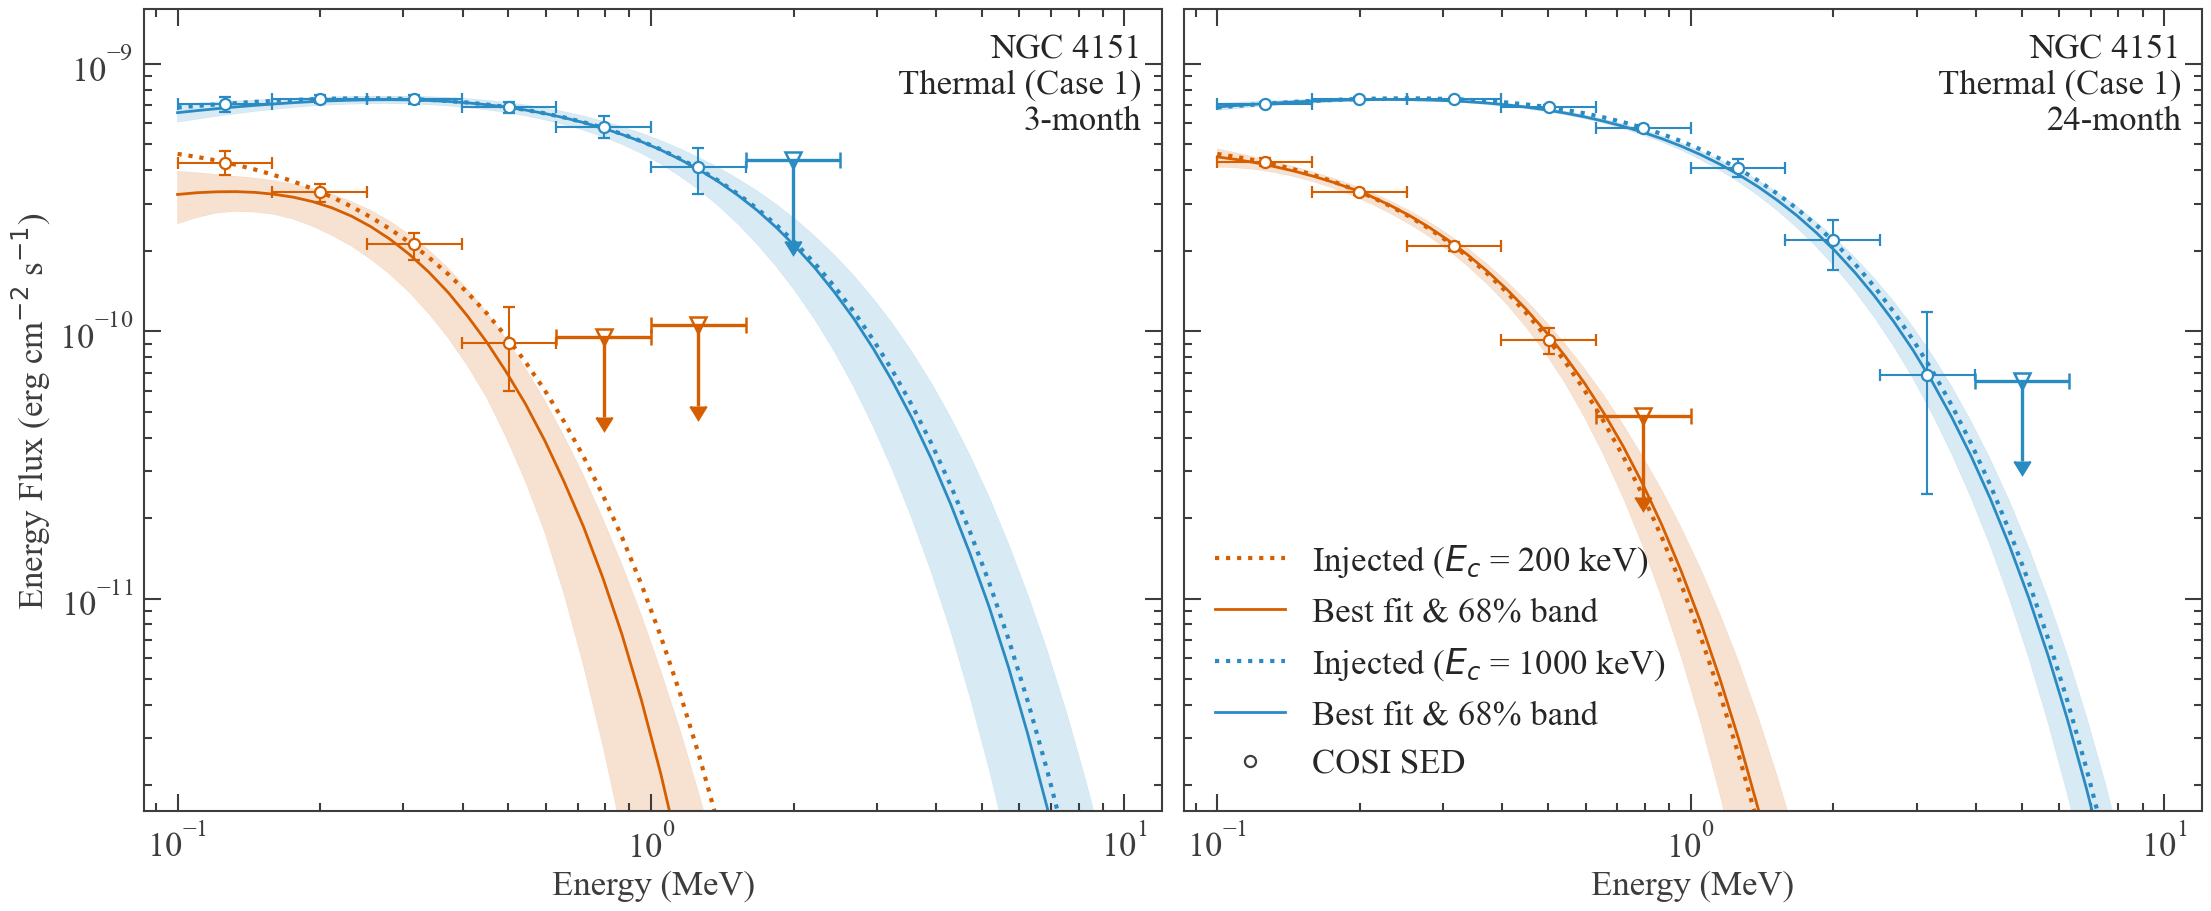

In [28]:
# Plot B uses the bin-by-bin median flux and median TS from all 300 seeds.
print('Plot B: 300-seed ensemble median SED; classification uses median bin TS.')

FONT_SIZE = 25

plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update(
    {
        "font.weight": "550",
        "axes.titleweight": "550",
        "axes.labelweight": "550",
    }
)

def _make_xerr(df):
    return KEV_TO_MEV * np.vstack(
        [
            df["e_ref_keV"] - df["e_min_keV"],
            df["e_max_keV"] - df["e_ref_keV"],
        ]
    )


def _split_sed_detections(df, ts_threshold=4.0, min_plot_ts=1.0):
    if 'plot_role' in df.columns:
        roles = df['plot_role'].astype(str)
        return (
            df.loc[roles == 'detection'].copy(),
            df.loc[roles == 'upper_limit'].copy(),
        )

    plot_mask = np.ones(len(df), dtype=bool)
    upper_limit_mask = df['is_upper_limit'].copy()

    if 'ts_value' in df.columns:
        plot_mask = df['ts_value'] >= min_plot_ts
        upper_limit_mask = upper_limit_mask | (df['ts_value'] < ts_threshold)

    return (
        df.loc[plot_mask & ~upper_limit_mask].copy(),
        df.loc[plot_mask & upper_limit_mask].copy(),
    )


def _plot_sed_points(ax, det, ul, marker, color, facecolor, label):
    if not det.empty:
        detection_yerr = np.vstack(
            [
                np.maximum(det['sed_erg_cm2_s'] - det['sed_lo_erg_cm2_s'], 0),
                np.maximum(det['sed_hi_erg_cm2_s'] - det['sed_erg_cm2_s'], 0),
            ]
        )

        ax.errorbar(
            det['e_ref_keV'] * KEV_TO_MEV,
            det['sed_erg_cm2_s'],
            xerr=_make_xerr(det),
            yerr=detection_yerr,
            fmt=marker,
            color=color,
            ecolor=color,
            markerfacecolor=facecolor,
            markeredgecolor=color,
            markeredgewidth=1.6,
            elinewidth=1.5,
            capsize=4,
            markersize=8,
            label=label,
        )

    if not ul.empty:
        upper_y = ul['sed_hi_erg_cm2_s'].to_numpy()
        upper_yerr = np.maximum(0.5 * upper_y, np.finfo(float).tiny)

        ax.errorbar(
            ul['e_ref_keV'] * KEV_TO_MEV,
            upper_y,
            xerr=_make_xerr(ul),
            yerr=upper_yerr,
            uplims=True,
            fmt='v',
            color=color,
            ecolor=color,
            markerfacecolor='white',
            markeredgecolor=color,
            markeredgewidth=1.8,
            elinewidth=2.4,
            capsize=6,
            markersize=11,
            barsabove=True,
            zorder=6,
            label='_nolegend_',
        )


def _fit_includes_dataset(fit_results, dataset_name):
    try:
        return dataset_name in fit_results.get_statistic_frame().index
    except Exception:
        return False

has_bat_fit_200 = _fit_includes_dataset(results, 'BAT')
has_bat_fit_1000 = _fit_includes_dataset(results_ec1000, 'BAT')
has_bat_sed_200 = has_bat_fit_200 and 'thermal_bat_sed_df' in globals()
has_bat_sed_1000 = has_bat_fit_1000 and 'thermal_bat_sed_df_ec1000' in globals()
has_any_bat_fit = has_bat_fit_200 or has_bat_fit_1000
fit_label = 'Global joint fit' if has_any_bat_fit else 'Global COSI-only fit'
fit_suffix = 'Joint' if has_any_bat_fit else 'COSI'

n_cosi_sed_bins_200 = len(ensemble_thermal_cosi_sed_df)
n_cosi_sed_bins_1000 = len(ensemble_thermal_cosi_sed_df_ec1000)
n_bat_sed_bins_200 = len(thermal_bat_sed_df) if has_bat_sed_200 else 0
n_bat_sed_bins_1000 = len(thermal_bat_sed_df_ec1000) if has_bat_sed_1000 else 0

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

det_cosi_200, ul_cosi_200 = _split_sed_detections(ensemble_thermal_cosi_sed_df)
det_cosi_1000, ul_cosi_1000 = _split_sed_detections(ensemble_thermal_cosi_sed_df_ec1000)

if has_bat_sed_200:
    det_bat_200, ul_bat_200 = _split_sed_detections(thermal_bat_sed_df)
else:
    det_bat_200 = pd.DataFrame()
    ul_bat_200 = pd.DataFrame()

if has_bat_sed_1000:
    det_bat_1000, ul_bat_1000 = _split_sed_detections(thermal_bat_sed_df_ec1000)
else:
    det_bat_1000 = pd.DataFrame()
    ul_bat_1000 = pd.DataFrame()

# Okabe-Ito colors: color encodes cutoff energy throughout the plot.
COLOR_200 = '#D55E00'
COLOR_1000 = '#2A8BC3'
FACE_200 = '#F6D7C9'
FACE_1000 = 'white'

ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_inj,
    color=COLOR_200,
    ls=':',
    lw=3,
    label='Injected thermal model ($E_{c}$ = 200 keV)',
)
ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_median,
    color=COLOR_200,
    lw=2,
    label=f'{fit_label} ($E_{{c}}$ = 200 keV)',
)
ax.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_lo,
    SED_KEV_TO_ERG * energy * energy * flux_hi,
    alpha=0.18,
    color=COLOR_200,
)

ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_inj_ec1000,
    color=COLOR_1000,
    ls=':',
    lw=3,
    label='Injected thermal model ($E_{c}$ = 1000 keV)',
)
ax.plot(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_median_ec1000,
    color=COLOR_1000,
    lw=2,
    label=f'{fit_label} ($E_{{c}}$ = 1000 keV)',
)
ax.fill_between(
    energy * KEV_TO_MEV,
    SED_KEV_TO_ERG * energy * energy * flux_lo_ec1000,
    SED_KEV_TO_ERG * energy * energy * flux_hi_ec1000,
    alpha=0.18,
    color=COLOR_1000,
)

_plot_sed_points(
    ax,
    det_cosi_200,
    ul_cosi_200,
    marker='o',
    color=COLOR_200,
    facecolor='white',
    label=f'COSI bin-by-bin SED ($E_{{c}}$ = 200 keV; {len(det_cosi_200)} detections out of {n_cosi_sed_bins_200} bins)',
)
_plot_sed_points(
    ax,
    det_cosi_1000,
    ul_cosi_1000,
    marker='o',
    color=COLOR_1000,
    facecolor='white',
    label=f'COSI bin-by-bin SED ($E_{{c}}$ = 1000 keV; {len(det_cosi_1000)} detections out of {n_cosi_sed_bins_1000} bins)',
)
if has_bat_sed_200:
    _plot_sed_points(
        ax,
        det_bat_200,
        ul_bat_200,
        marker='^',
        color=COLOR_200,
        facecolor=FACE_200,
        label=f'BAT bin-by-bin SED ($E_{{c}}$ = 200 keV; {len(det_bat_200)} detections out of {n_bat_sed_bins_200} bins)',
    )
if has_bat_sed_1000:
    _plot_sed_points(
        ax,
        det_bat_1000,
        ul_bat_1000,
        marker='^',
        color=COLOR_1000,
        facecolor=FACE_1000,
        label=f'BAT bin-by-bin SED ($E_{{c}}$ = 1000 keV; {len(det_bat_1000)} detections out of {n_bat_sed_bins_1000} bins)',
    )

legend_handles = [
    plt.Line2D([], [], color=COLOR_200, ls=':', lw=3, label='Injected ($E_{c}$ = 200 keV)'),
    plt.Line2D([], [], color=COLOR_200, lw=2, label='Best fit & 68% band'),
    plt.Line2D([], [], color=COLOR_1000, ls=':', lw=3, label='Injected ($E_{c}$ = 1000 keV)'),
    plt.Line2D([], [], color=COLOR_1000, lw=2, label='Best fit & 68% band'),
]

if not det_cosi_200.empty or not det_cosi_1000.empty:
    legend_handles.append(
        plt.Line2D([], [], color='0.25', marker='o', markerfacecolor='white', markeredgewidth=1.6, linestyle='None', markersize=8, label='COSI SED')
    )

if has_bat_sed_200 and not det_bat_200.empty:
    legend_handles.append(
        plt.Line2D([], [], color=COLOR_200, marker='^', markerfacecolor=FACE_200, markeredgewidth=1.6, linestyle='None', markersize=8, label='BAT SED')
    )

if has_bat_sed_1000 and not det_bat_1000.empty:
    legend_handles.append(
        plt.Line2D([], [], color=COLOR_1000, marker='^', markerfacecolor=FACE_1000, markeredgewidth=1.6, linestyle='None', markersize=8, label='BAT SED')
    )

ax.text(
    0.98, 0.97,
    f'NGC 4151\nThermal (Case 1)\n{exposure_4151}-month',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim((85) * KEV_TO_MEV, (12000) * KEV_TO_MEV)
# ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 5, 10]))
# ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.1", "5", "10"]))

ax.set_ylim(5e-8 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)

ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
ax.set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
ax.legend(handles=legend_handles, fontsize=FONT_SIZE, loc='lower left', frameon=False)

# Replace the legacy single-exposure figure above with the requested
# side-by-side 3-month and 24-month comparison.
plt.close(fig)

exposure_panels = [
    {
        'exposure_months': 3,
        'flux_median_200': flux_median,
        'flux_lo_200': flux_lo,
        'flux_hi_200': flux_hi,
        'sed_200': ensemble_thermal_cosi_sed_df,
        'flux_median_1000': flux_median_ec1000,
        'flux_lo_1000': flux_lo_ec1000,
        'flux_hi_1000': flux_hi_ec1000,
        'sed_1000': ensemble_thermal_cosi_sed_df_ec1000,
    },
    {
        'exposure_months': 24,
        'flux_median_200': flux_median_24m,
        'flux_lo_200': flux_lo_24m,
        'flux_hi_200': flux_hi_24m,
        'sed_200': ensemble_thermal_cosi_sed_df_24m,
        'flux_median_1000': flux_median_ec1000_24m,
        'flux_lo_1000': flux_lo_ec1000_24m,
        'flux_hi_1000': flux_hi_ec1000_24m,
        'sed_1000': ensemble_thermal_cosi_sed_df_ec1000_24m,
    },
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(22, 9),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for panel_ax, panel in zip(axes, exposure_panels):
    panel_ax.xaxis.set_tick_params(
        which='major', size=12, width=1.5, direction='in', top=True,
        pad=8, labelsize=FONT_SIZE,
    )
    panel_ax.xaxis.set_tick_params(
        which='minor', size=6, width=1.5, direction='in', top=True, pad=8,
    )
    panel_ax.yaxis.set_tick_params(
        which='major', size=12, width=1.5, direction='in', right=True,
        pad=8, labelsize=FONT_SIZE,
    )
    panel_ax.yaxis.set_tick_params(
        which='minor', size=6, width=1.5, direction='in', right=True, pad=8,
    )
    panel_ax.spines['right'].set_visible(True)
    panel_ax.spines['top'].set_visible(True)

    det_200, ul_200 = _split_sed_detections(panel['sed_200'])
    det_1000, ul_1000 = _split_sed_detections(panel['sed_1000'])

    panel_ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * flux_inj,
        color=COLOR_200, ls=':', lw=3, label='_nolegend_',
    )
    panel_ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * panel['flux_median_200'],
        color=COLOR_200, lw=2, label='_nolegend_',
    )
    panel_ax.fill_between(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * panel['flux_lo_200'],
        SED_KEV_TO_ERG * energy**2 * panel['flux_hi_200'],
        alpha=0.18, color=COLOR_200,
    )

    panel_ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * flux_inj_ec1000,
        color=COLOR_1000, ls=':', lw=3, label='_nolegend_',
    )
    panel_ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * panel['flux_median_1000'],
        color=COLOR_1000, lw=2, label='_nolegend_',
    )
    panel_ax.fill_between(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * panel['flux_lo_1000'],
        SED_KEV_TO_ERG * energy**2 * panel['flux_hi_1000'],
        alpha=0.18, color=COLOR_1000,
    )

    _plot_sed_points(
        panel_ax, det_200, ul_200, marker='o', color=COLOR_200,
        facecolor='white', label='_nolegend_',
    )
    _plot_sed_points(
        panel_ax, det_1000, ul_1000, marker='o', color=COLOR_1000,
        facecolor='white', label='_nolegend_',
    )

    panel_ax.text(
        0.98,
        0.97,
        f"NGC 4151\nThermal (Case 1)\n{panel['exposure_months']}-month",
        transform=panel_ax.transAxes,
        ha='right', va='top', fontsize=FONT_SIZE, fontweight='550',
    )
    panel_ax.set_xscale('log')
    panel_ax.set_yscale('log')
    panel_ax.set_xlim(85 * KEV_TO_MEV, 12000 * KEV_TO_MEV)
    panel_ax.set_ylim(1e-3 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)
    panel_ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)

axes[0].set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
axes[1].legend(
    handles=legend_handles, fontsize=FONT_SIZE, loc='lower left', frameon=False,
)

save_path = (
    '/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/'
    'Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/'
    'NGC4151_ThModel_TH_200_1000_3_24Months_COSI_TwoPanel_SED_300SeedMedianSED.pdf'
)
# Plot B is displayed but intentionally not saved.
plt.show()


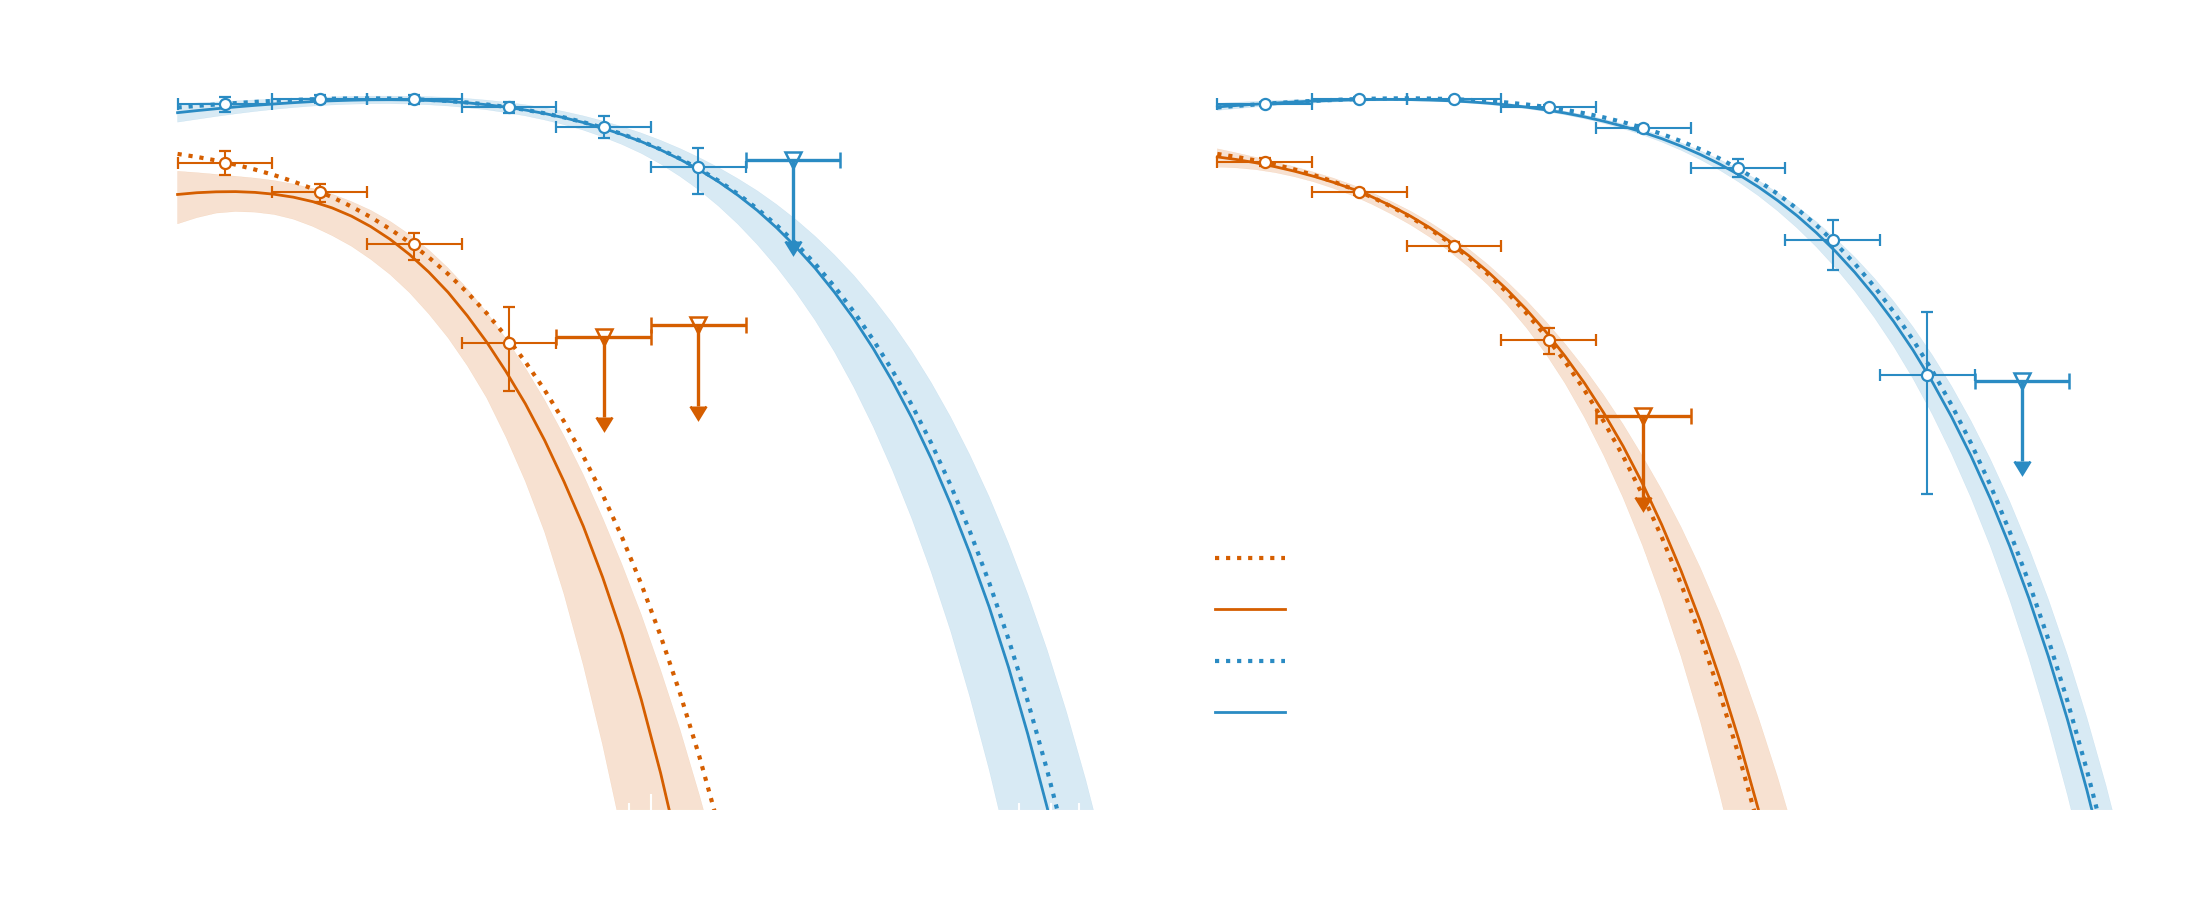

In [29]:
# Transparent canvas with a white foreground for copying onto a dark background.
def _apply_transparent_dark_style(fig, axis):
    foreground_color = 'white'

    fig.patch.set_alpha(0)
    axis.patch.set_alpha(0)
    axis.tick_params(axis='both', which='both', colors=foreground_color)
    axis.xaxis.label.set_color(foreground_color)
    axis.yaxis.label.set_color(foreground_color)

    for spine in axis.spines.values():
        spine.set_color(foreground_color)

    for annotation in axis.texts:
        annotation.set_color(foreground_color)

    legend = axis.get_legend()
    if legend is not None:
        legend.get_frame().set_alpha(0)
        legend.get_frame().set_edgecolor(foreground_color)
        for legend_text in legend.get_texts():
            legend_text.set_color(foreground_color)
        for handle in getattr(legend, 'legend_handles', []):
            if handle.get_label() == 'COSI SED':
                handle.set_color(foreground_color)
                handle.set_markeredgecolor(foreground_color)
                handle.set_markerfacecolor('none')


for panel_ax in axes:
    _apply_transparent_dark_style(fig, panel_ax)

display(fig)